# **Used Cars Price Prediction**

## **Problem Definition**

### **The Context:**

 - Why is this problem important to solve?

### **The objective:**

 - What is the intended goal?

### **The key questions:**

- What are the key questions that need to be answered?

### **The problem formulation**:

- What is it that we are trying to solve using data science?

### **Data Dictionary**

**S.No.** : Serial Number

**Name** : Name of the car which includes Brand name and Model name

**Location** : The location in which the car is being sold or is available for purchase (Cities)

**Year** : Manufacturing year of the car

**Kilometers_driven** : The total kilometers driven in the car by the previous owner(s) in KM

**Fuel_Type** : The type of fuel used by the car (Petrol, Diesel, Electric, CNG, LPG)

**Transmission** : The type of transmission used by the car (Automatic / Manual)

**Owner** : Type of ownership

**Mileage** : The standard mileage offered by the car company in kmpl or km/kg

**Engine** : The displacement volume of the engine in CC

**Power** : The maximum power of the engine in bhp

**Seats** : The number of seats in the car

**New_Price** : The price of a new car of the same model in INR 100,000

**Price** : The price of the used car in INR 100,000 (**Target Variable**)

## **Important Notes**

- This notebook can be considered a guide to refer to while solving the problem. The evaluation will be as per the Rubric shared for the Capstone. Unlike previous courses, it does not follow the pattern of the graded questions in different sections. This notebook will give you a direction on what steps need to be taken in order to get a viable solution to the problem. Please note that this is just one way of doing this. There can be other 'creative' ways to solve the problem and we urge you to feel free and explore them as an 'optional' exercise.

- In the notebook, there are markdown cells called - Observations and Insights. It is a good practice to provide observations and extract insights from the outputs.

- The naming convention for different variables can vary. Please consider the code provided in this notebook as a sample code.

- All the outputs in the notebook are just for reference and can be different if you follow a different approach.

- There are sections called **Think About It** in the notebook that will help you get a better understanding of the reasoning behind a particular technique/step. Interested learners can take alternative approaches if they wish to explore different techniques.

### **Loading libraries**

In [1]:
# Google drive mounten
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries to build linear model for statistical analysis and prediction
# Import statsmodels.stats.api as sms
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor,RandomForestRegressor

from sklearn.model_selection import train_test_split

# Metrics to evaluate the model
from sklearn import metrics

# For tuning the model
from sklearn.model_selection import GridSearchCV

# To ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Removes the limit from the number of displayed columns and rows
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

### **Let us load the data**

In [3]:
# define path
path = "/content/drive/MyDrive/ML_Projects/5_Capstone_Used_Car_Price/used_cars.csv"

# load dataset
data = pd.read_csv(path)

### **Understand the data by observing a few rows**

In [4]:
# View first 5 rows
data.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,8.61,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,NaN,17.74


In [5]:
# View last 5 rows Hint: Use tail() method
data.tail()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price
7248,7248,Volkswagen Vento Diesel Trendline,Hyderabad,2011,89411,Diesel,Manual,First,20.54,1598.0,103.6,5.0,NaN,NaN
7249,7249,Volkswagen Polo GT TSI,Mumbai,2015,59000,Petrol,Automatic,First,17.21,1197.0,103.6,5.0,NaN,NaN
7250,7250,Nissan Micra Diesel XV,Kolkata,2012,28000,Diesel,Manual,First,23.08,1461.0,63.1,5.0,NaN,NaN
7251,7251,Volkswagen Polo GT TSI,Pune,2013,52262,Petrol,Automatic,Third,17.20,1197.0,103.6,5.0,NaN,NaN
7252,7252,Mercedes-Benz E-Class 2009-2013 E 220 CDI Avan...,Kochi,2014,72443,Diesel,Automatic,First,10.00,2148.0,170.0,5.0,NaN,NaN


**Observations and Insights: _____**

Observation 1 – Dataset structure

The dataset contains information about used cars including attributes such as brand and model name, location, year of manufacture, kilometers driven, fuel type, transmission type, engine specifications, and selling price.

Observation 2 – Target variable

The target variable of interest is Price, which represents the resale value of the used car.

Observation 3 – Feature types

The dataset contains a mixture of:

Numerical variables (Year, Kilometers_Driven, Engine, Power, Seats, Price)

Categorical variables (Location, Fuel_Type, Transmission, Owner_Type)

Observation 4 – Potential missing values

From the preview we can already observe that some columns such as New_Price contain missing values (NaN), which will require further investigation and treatment during data preprocessing.

Observation 5 – Vehicle characteristics

Most vehicles appear to have 5 seats, and the dataset includes different fuel types such as Petrol, Diesel, and CNG

### **Let us check the data types and and missing values of each column**

In [6]:
# Check the datatypes of each column. Hint: Use info() method
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   object 
 2   Location           7253 non-null   object 
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7251 non-null   float64
 9   Engine             7207 non-null   float64
 10  Power              7078 non-null   float64
 11  Seats              7200 non-null   float64
 12  New_price          1006 non-null   float64
 13  Price              6019 non-null   float64
dtypes: float64(6), int64(3), object(5)
memory usage: 793.4+ KB


In [7]:
# Check total number of missing values of each column. Hint: Use isnull() method
data.isnull().sum()

,0
S.No.,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,2
Engine,46


**Observations and Insights: _____**

Observation 1 – Dataset size

The dataset contains 7253 observations and 14 columns, representing different attributes of used cars such as brand, location, fuel type, engine capacity, and price.

Observation 2 – Data types

The dataset includes a mix of numerical variables and categorical variables.

Numerical variables include: Year, Kilometers_Driven, Mileage, Engine, Power, Seats, and Price.

Categorical variables include: Name, Location, Fuel_Type, Transmission, and Owner_Type.

This indicates that some features will require encoding before applying machine learning models.

Observation 3 – Missing values

Some variables contain missing values:

Column	Missing Values
Mileage	2
Engine	46
Power	175
Seats	53
New_Price	6247
Price	1234

The New_Price column has a very large number of missing values, which may require special treatment or removal during preprocessing.

Observation 4 – Target variable

The target variable Price also contains missing values (1234 rows).
These observations may need to be removed since the price is required for model training.

Observation 5 – Index column

The column S.No. appears to be a simple index column with no predictive value and can therefore be removed from the dataset.

We can observe that `S.No.` has no null values. Also the number of unique values are equal to the number of observations. So, `S.No.` looks like an index for the data entry and such a column would not be useful in providing any predictive power for our analysis. Hence, it can be dropped.

In [8]:
# Remove S.No. column from data. Hint: Use inplace = True
data.drop("S.No.", axis=1, inplace=True)

## **Exploratory Data Analysis**

### **Let us now explore the summary statistics of numerical variables**

In [9]:
# Explore basic summary statistics of numeric variables. Hint: Use describe() method.
data.describe()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,New_price,Price
count,7253.000000,7.253000e+03,7251.000000,7207.000000,7078.000000,7200.000000,1006.000000,6019.000000
mean,2013.365366,5.869906e+04,18.141580,1616.573470,112.765214,5.280417,22.779692,9.479468
std,3.254421,8.442772e+04,4.562197,595.285137,53.493553,0.809277,27.759344,11.187917
min,1996.000000,1.710000e+02,0.000000,72.000000,34.200000,2.000000,3.910000,0.440000
25%,2011.000000,3.400000e+04,15.170000,1198.000000,75.000000,5.000000,7.885000,3.500000
50%,2014.000000,5.341600e+04,18.160000,1493.000000,94.000000,5.000000,11.570000,5.640000
75%,2016.000000,7.300000e+04,21.100000,1968.000000,138.100000,5.000000,26.042500,9.950000
max,2019.000000,6.500000e+06,33.540000,5998.000000,616.000000,10.000000,375.000000,160.000000


In [10]:
# The target variable Price is expressed in Lakhs (1 Lakh = 100,000 INR), which is a standard unit in the Indian automotive market.
# This explains the relatively small numerical values (e.g., mean ≈ 9.48), corresponding to approximately 948,000 INR.

data["Price"].head()

,Price
0,1.75
1,12.50
2,4.50
3,6.00
4,17.74


**Observations and Insights: _____**

1. Vehicle Age Distribution

The Year variable ranges from 1996 to 2019, with a median value of 2014.
This indicates that the dataset mainly consists of relatively modern vehicles, although some older cars are also present.

2. Kilometers Driven

The number of kilometers driven varies significantly, ranging from 171 km to 6.5 million km, with a median of approximately 53,416 km.
The very high maximum value suggests the presence of possible outliers or data entry errors, which may need further investigation during data cleaning.

3. Engine Capacity

The engine capacity ranges from 72 cc to 5998 cc, with an average of around 1616 cc.
This indicates that the dataset includes a wide variety of vehicles, from small economy cars to high-performance luxury vehicles.

4. Power

The Power variable ranges from 34 bhp to 616 bhp, which again shows a large diversity of vehicles in terms of performance.
Higher power values are likely associated with higher resale prices.

5. Seats

The Seats variable has a median of 5 seats, indicating that most cars in the dataset are standard passenger vehicles.

6. New Price

The New_Price variable shows a large variation and has significantly fewer observations compared to other variables, indicating a large number of missing values in this column.

7. Price Distribution

The resale price ranges from 0.44 to 160, with a median value of 5.64.
The wide range suggests that the dataset includes both low-cost used vehicles and premium cars, which could influence model performance.

8. Addtional Insight – Price Distribution

The mean price (9.47) is significantly higher than the median price (5.64), which suggests that the price distribution is right-skewed. This indicates that a relatively small number of very expensive vehicles increase the average price. Such skewed distributions are common in used car markets where a few luxury or high-performance vehicles command significantly higher prices. This skewness may need to be considered during modeling, for example by applying a log transformation to the price variable.

### **Let us also explore the summary statistics of all categorical variables and the number of unique observations in each category**

In [11]:
# Explore basic summary statistics of categorical variables. Hint: Use the argument include = ['object']
data.describe(include=['object'])

,Name,Location,Fuel_Type,Transmission,Owner_Type
count,7253,7253,7253,7253,7253
unique,2041,11,5,2,4
top,Mahindra XUV500 W8 2WD,Mumbai,Diesel,Manual,First
freq,55,949,3852,5204,5952


**Number of unique observations in each category**

In [12]:
cat_cols = data.select_dtypes(include = ['object']).columns

for column in cat_cols:

    print("For column:", column)

    print(data[column].nunique())

    print('-'*50)

For column: Name
2041
--------------------------------------------------
For column: Location
11
--------------------------------------------------
For column: Fuel_Type
5
--------------------------------------------------
For column: Transmission
2
--------------------------------------------------
For column: Owner_Type
4
--------------------------------------------------


#### **Observations and Insights: _____**

1. Name

The Name column contains 2041 unique values, indicating that the dataset includes a large variety of car models. Since this variable combines both brand and model information, it may be useful to extract the car brand as a separate feature for further analysis.

2. Location

The Location variable contains 11 unique values, representing the cities where the cars are being sold. This variable may capture regional differences in used car prices.

3. Fuel Type

The Fuel_Type variable has 5 unique categories, with Diesel being the most common fuel type in the dataset. Fuel type can influence resale value due to differences in fuel efficiency and operating costs.

4. Transmission

The Transmission variable has only two categories: Manual and Automatic, with Manual transmission appearing much more frequently. This suggests that most cars in the dataset are manual vehicles.

5. Owner Type

The Owner_Type variable has 4 categories, with First owner vehicles being the most common. Vehicles with fewer previous owners may generally have higher resale values.

6. Additional Insight
The Name variable contains a very high number of unique values, which may make it difficult to use directly in machine learning models. Therefore, extracting useful information such as the car brand could help reduce dimensionality and improve model performance.

**Think About It**:

- We could observe from summary statistics that kilometers_driven has extreme values. Can we look at the manufactured year for cars with extreme values for kilometers_driven?
- Also, we could observe the feature mileage has values zero. Can the mileage of a car be zero?

**Let's explore the two points mentioned above**

**Check Kilometers_Driven extreme values**

In [13]:
# Sort the dataset in 'descending' order using the feature 'Kilometers_Driven'
data.sort_values(by="Kilometers_Driven", ascending=False).head(10)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price
2328,BMW X5 xDrive 30d M Sport,Chennai,2017,6500000,Diesel,Automatic,First,15.97,2993.0,258.00,5.0,NaN,65.00
340,Skoda Octavia Ambition Plus 2.0 TDI AT,Kolkata,2013,775000,Diesel,Automatic,First,19.30,1968.0,141.00,5.0,NaN,7.50
1860,Volkswagen Vento Diesel Highline,Chennai,2013,720000,Diesel,Manual,First,20.54,1598.0,103.60,5.0,NaN,5.90
358,Hyundai i10 Magna 1.2,Chennai,2009,620000,Petrol,Manual,First,20.36,1197.0,78.90,5.0,NaN,2.70
2823,Volkswagen Jetta 2013-2015 2.0L TDI Highline AT,Chennai,2015,480000,Diesel,Automatic,First,16.96,1968.0,138.03,5.0,NaN,13.00
3092,Honda City i VTEC SV,Kolkata,2015,480000,Petrol,Manual,First,17.40,1497.0,117.30,5.0,NaN,5.00
4491,Hyundai i20 Magna Optional 1.2,Bangalore,2013,445000,Petrol,Manual,First,18.50,1197.0,82.90,5.0,NaN,4.45
6921,Maruti Swift Dzire Tour LDI,Jaipur,2012,350000,Diesel,Manual,First,23.40,1248.0,74.00,5.0,NaN,NaN
3649,Tata Indigo LS,Jaipur,2008,300000,Diesel,Manual,First,17.00,1405.0,70.00,5.0,NaN,1.00
1528,Toyota Innova 2.5 G (Diesel) 8 Seater BS IV,Hyderabad,2005,299322,Diesel,Manual,First,12.80,2494.0,102.00,8.0,NaN,4.00


#### **Observations and Insights: _____**


Observations and Insights

We observe some extremely high values for the variable Kilometers_Driven. In particular, the vehicle with the highest value is a BMW X5 xDrive 30d M Sport from 2017, which is reported to have driven 6.5 million kilometers.

Given the relatively recent manufacturing year of the vehicle, such a mileage appears highly unrealistic for a typical passenger car. This likely indicates either a data entry error or a special case (outlier) in the dataset.

Such extreme values can significantly distort statistical analysis and negatively affect machine learning models. Therefore, these observations should be further investigated and potentially treated during the data preprocessing stage, for example by removing or correcting unrealistic mileage values.

Most other high-mileage vehicles in the list have values between 300,000 and 775,000 km, which is already high but still plausible for older vehicles. The value of 6.5 million km is therefore clearly an extreme outlier.

In the first row, a car manufactured as recently as 2017 having been driven 6500000 km is almost impossible. It can be considered as data entry error and so we can remove this value/entry from data.

In [14]:
# Removing the 'row' at index 2328 from the data. Hint: use the argument inplace=True
data.drop(2328, inplace=True)

**Check Mileage extreme values**

In [15]:
# Sort the dataset in 'ascending' order using the feature 'Mileage'
data.sort_values(by="Mileage", ascending=True).head(10)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price
3033,Hyundai Santro Xing XP,Jaipur,2005,120000,Petrol,Manual,First,0.0,1086.0,NaN,5.0,NaN,1.15
67,Mercedes-Benz C-Class Progressive C 220d,Coimbatore,2019,15369,Diesel,Automatic,First,0.0,1950.0,194.0,5.0,49.14,35.67
14,Land Rover Freelander 2 TD4 SE,Pune,2012,85000,Diesel,Automatic,Second,0.0,2179.0,115.0,5.0,NaN,17.50
749,Land Rover Range Rover 3.0 D,Mumbai,2008,55001,Diesel,Automatic,Second,0.0,NaN,NaN,NaN,NaN,26.50
3044,Hyundai Santro Xing GL,Kolkata,2009,60170,Petrol,Manual,First,0.0,1086.0,62.0,5.0,NaN,1.15
5426,Hyundai Santro Xing XL,Chennai,2006,85000,Petrol,Manual,Third,0.0,1086.0,NaN,5.0,NaN,1.30
5875,Mercedes-Benz C-Class Progressive C 220d,Ahmedabad,2019,4000,Diesel,Automatic,First,0.0,1950.0,194.0,5.0,49.14,35.00
3061,Hyundai Santro GS,Ahmedabad,2005,58000,Petrol,Manual,Second,0.0,999.0,NaN,5.0,NaN,1.51
4412,Mercedes-Benz M-Class ML 350 4Matic,Coimbatore,2016,27833,Diesel,Automatic,First,0.0,2987.0,165.0,5.0,NaN,49.24
962,Mercedes-Benz C-Class Progressive C 220d,Mumbai,2018,8682,Diesel,Automatic,First,0.0,1950.0,194.0,5.0,52.26,39.50


#### **Observations**
* Mileage of cars can not be 0, so we should treat 0's as missing values. We will do it in the Feature Engineering part.

## **Univariate Analysis**
Univariate analysis is used to explore each variable in a data set, separately. It looks at the range of values, as well as the central tendency of the values. It can be done for both numerical and categorical variables.

## **1. Univariate Analysis - Numerical Data**
Histograms and box plots help to visualize and describe numerical data. We use box plot and histogram to analyse the numerical columns.

In [16]:
# Function to plot a boxplot and a histogram along the same scale

def histogram_boxplot(data, feature, figsize = (12, 7), kde = False, bins = None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows = 2,      # Number of rows of the subplot grid = 2
        sharex = True,  # x-axis will be shared among all subplots
        gridspec_kw = {"height_ratios": (0.25, 0.75)},
        figsize = figsize,
    )                   # Creating the 2 subplots
    sns.boxplot(
        data = data, x = feature, ax = ax_box2, showmeans = True, color = "violet"
    )                   # Boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2, bins = bins, palette = "winter"
    ) if bins else sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2
    )                   # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color = "green", linestyle = "--"
    )                   # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color = "black", linestyle = "-"
    )                   # Add median to the histogram

**Let us plot histogram and box-plot for the feature 'Kilometers_Driven' to understand the distribution and outliers, if any.**

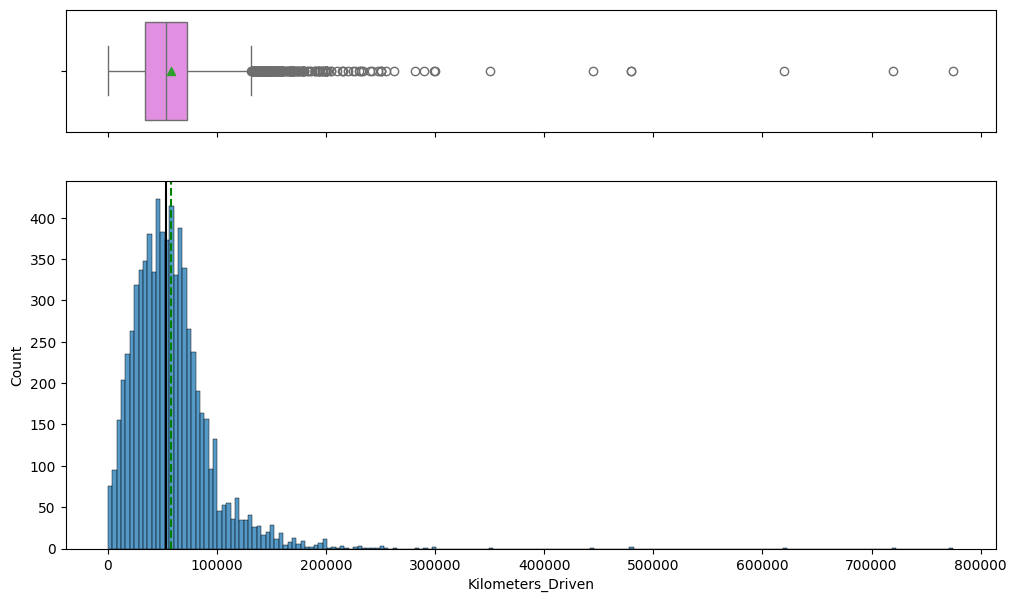

In [17]:
# Plot histogram and box-plot for 'Kilometers_Driven'
histogram_boxplot(data, 'Kilometers_Driven')

**Think About It**: Kilometers_Driven is highly right-skewed. Can we use Log transformation of the feature to reduce/remove the skewness? Why can't we keep skewed data?

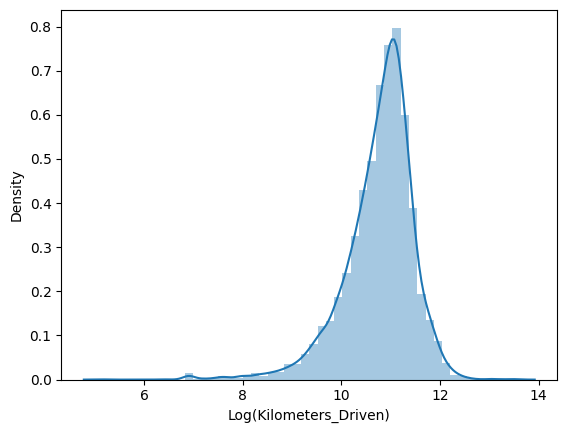

In [18]:
# Log transformation of the feature 'Kilometers_Driven'
sns.distplot(np.log(data["Kilometers_Driven"]), axlabel = "Log(Kilometers_Driven)");

**Observations and Insights: _____**

Observations and Insights

The distribution of the feature Kilometers_Driven is highly right-skewed, as shown by both the histogram and the boxplot. Most vehicles have driven between 30,000 and 100,000 kilometers, while a small number of vehicles show extremely high mileage values.

These extreme values create a long right tail in the distribution, indicating the presence of outliers and skewness. Such skewed distributions are common in real-world datasets but can negatively affect the performance of certain machine learning models.

After applying a log transformation to the feature, the distribution becomes much more symmetric and closer to a normal distribution. This transformation reduces the impact of extreme values and can improve model stability and predictive performance.

The log transformation compresses large mileage values and reduces skewness, making the feature more suitable for machine learning algorithms.

The feature Kilometers_Driven appears to follow a log-normal distribution, which is common for many real-world economic and technical variables. Such distributions arise when a variable is influenced by multiple multiplicative factors. Applying a log transformation helps normalize the distribution and reduces the influence of extreme values, making the feature more suitable for machine learning models.

In [19]:
# We can add a transformed kilometers_driven feature in data
data["kilometers_driven_log"] = np.log(data["Kilometers_Driven"])

**Note:** Like Kilometers_Driven, the distribution of Price is also highly skewed, we can use log transformation on this column to see if that helps normalize the distribution. And add the transformed variable into the dataset. You can name the variable as **'price_log'**.

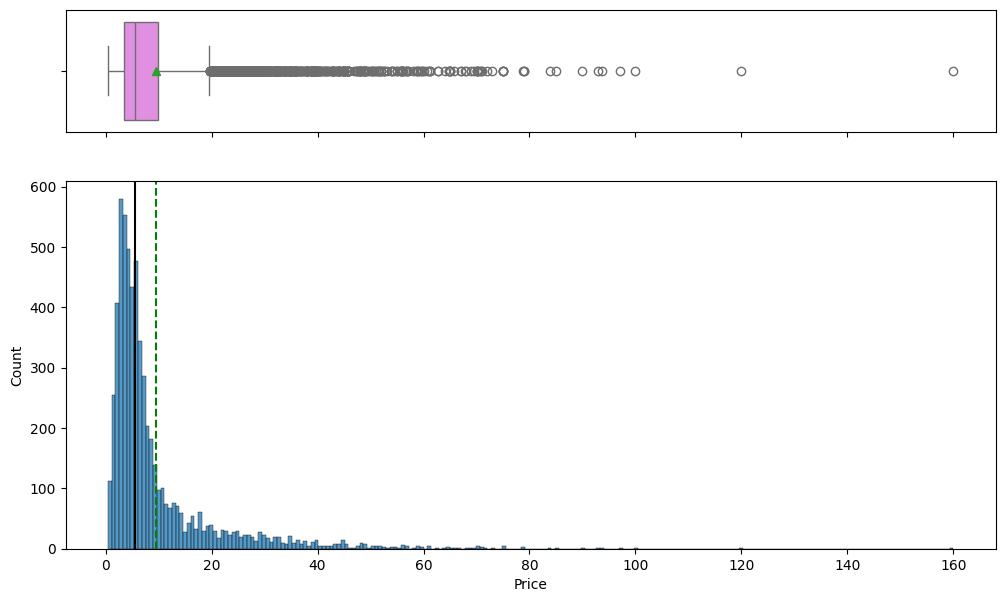

In [20]:
# Plot histogram and box-plot for 'Price'
histogram_boxplot(data, 'Price')

<Axes: xlabel='Log(Price)', ylabel='Density'>

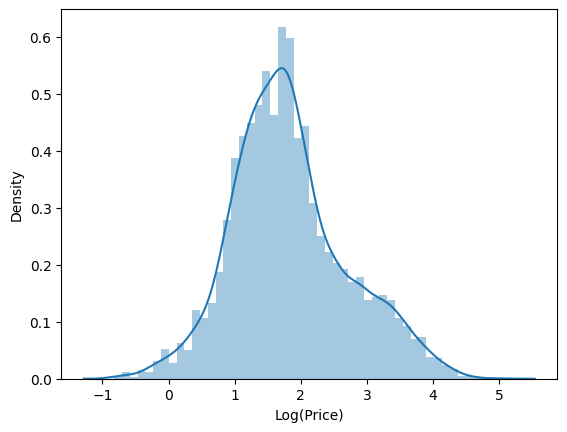

In [21]:
# Log transformation of the feature 'Price'
sns.distplot(np.log(data['Price']), axlabel='Log(Price)')

In [22]:
# We can Add a transformed Price feature in data
data['price_log'] = np.log(data['Price'])

**Note:** Try plotting histogram and box-plot for different numerical features and understand how the data looks like.

**Observations and Insights for all the plots: _____**


Observations and Insights for all the plots

The distribution of the Price variable is highly right-skewed, as shown by both the histogram and the boxplot. Most vehicles in the dataset have relatively low to moderate prices, while a smaller number of vehicles have very high prices, which creates a long right tail in the distribution.

The boxplot also highlights the presence of several outliers, representing high-value vehicles. These extreme values significantly increase the spread of the data and cause the mean to be higher than the median.

After applying a log transformation to the Price variable, the distribution becomes much more symmetric and closer to a normal distribution. The log transformation compresses large price values and reduces the influence of extreme observations.

This transformation is beneficial for machine learning models, as many algorithms perform better when the input variables follow a more normally distributed pattern. Therefore, the transformed variable price_log can be a more suitable feature for modeling compared to the original Price variable.

## **2. Univariate analysis - Categorical Data**

In [23]:
# Let us write a function that will help us create barplots that indicate the percentage for each category.
# This function takes the categorical column as the input and returns the barplots for the variable.


def perc_on_bar(data, z):
    '''
    plot
    data: DataFrame or Series
    z: categorical feature
    the function won't work if a column is passed in hue parameter
    '''

    total = len(data[z])  # Length of the column
    plt.figure(figsize=(15, 5))
    ax = sns.countplot(data=data, x=z, palette='Paired', order=data[z].value_counts().index)
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height() / total)  # Percentage of each class of the category
        x = p.get_x() + p.get_width() / 2 - 0.05  # Width of the plot
        y = p.get_y() + p.get_height()  # Height of the plot

        ax.annotate(percentage, (x, y), size=12, ha='center')  # Annotate the percentage with center alignment

    plt.show()

**Let us plot barplot for the variable location. It will be helpful to know the number of percentage of cars from each city.**

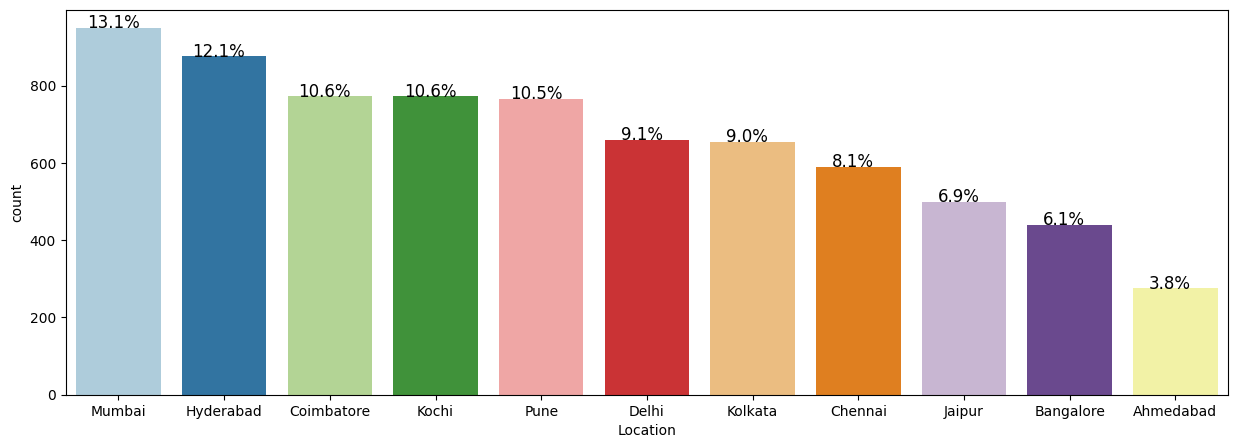

In [24]:
# Bar Plot for 'Location'
perc_on_bar(data, 'Location')

**Note:** Explore for other variables like Year, Fuel_Type, Transmission, Owner_Type`.

**Observations and Insights from all plots: _____**

Observations and Insights

The bar plot shows the distribution of used cars across different cities in the dataset. We observe that Mumbai has the highest proportion of cars (about 13%), followed by Hyderabad (around 12%). Cities such as Coimbatore, Kochi, and Pune also contribute a significant share of the observations, each accounting for roughly 10–11% of the dataset.

On the other hand, cities like Bangalore and Ahmedabad have a relatively smaller representation, with Ahmedabad contributing the lowest percentage (around 3.8%) of the cars in the dataset.

Overall, the dataset appears to be reasonably distributed across multiple cities, although some locations contribute more observations than others. This geographical variation may influence the price of used cars, since factors such as regional demand, economic conditions, and market size can differ across cities.


The relatively balanced distribution across several major cities suggests that the dataset captures a diverse representation of the used car market in India.


## **Bivariate Analysis**

### **1. Scatter plot**
A scatter plot allows us to see relationships between two variables.

**Note: Use log transformed values 'kilometers_driven_log' and 'price_log'**

<Axes: xlabel='price_log'>

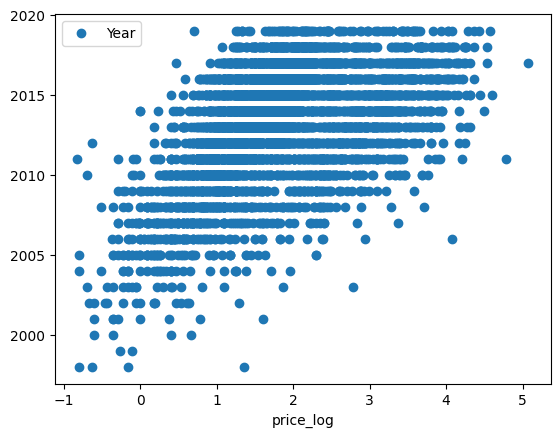

In [25]:
# Let us plot pair plot for the variables 'year' and 'price_log'
data.plot(x = 'price_log', y = 'Year', style = 'o')

<b>Note:</b> Try to explore different combinations of independent variables and dependent variable. Understand the relationship between all variables.

**Observations and Insights from all plots: _____**


Observations and Insights

The scatter plot illustrates the relationship between Year (manufacturing year) and log-transformed Price (price_log). We observe a positive relationship between these variables, indicating that newer vehicles tend to have higher prices compared to older vehicles.

However, there is still a considerable spread of prices within the same manufacturing year, suggesting that factors other than the vehicle's age also influence the price. These factors may include brand, engine capacity, mileage, fuel type, and other vehicle characteristics.

Overall, the plot confirms the expected trend that vehicle depreciation occurs over time, meaning that older vehicles generally have lower prices.

This relationship reflects the natural depreciation of vehicles over time, where the value of a car typically decreases as it ages.

### **2. Heat map**
Heat map shows a 2D correlation matrix between two numerical features.

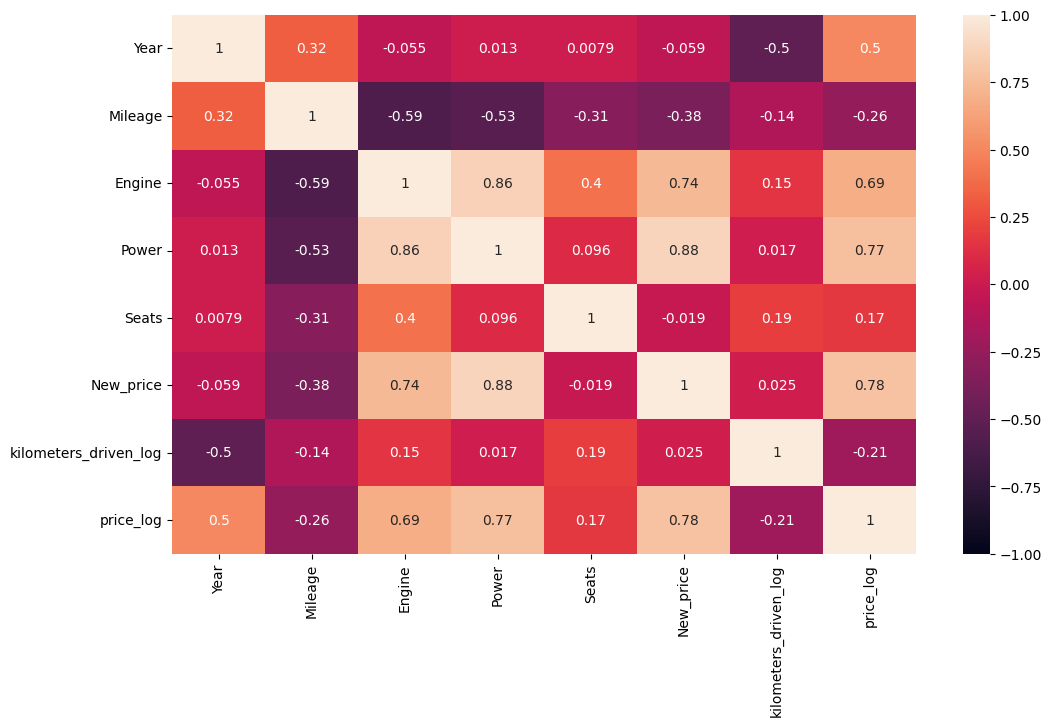

In [26]:
# We can include the log transformation values and drop the original skewed data columns
plt.figure(figsize = (12, 7))

sns.heatmap(data.drop(['Kilometers_Driven', 'Price'], axis=1).corr(numeric_only=True),
            annot=True, vmin=-1, vmax=1)

plt.show()

**Observations and Insights: _____**

Observations and Insights

The heatmap illustrates the correlation matrix between the numerical variables in the dataset and helps identify relationships between the different features.

One of the strongest positive correlations can be observed between Engine and Power (0.86), which is expected because larger engines typically produce higher power output.

A strong positive correlation also exists between Power and price_log (0.77) as well as Engine and price_log (0.69). This suggests that vehicles with higher engine capacity and greater power tend to have higher prices, which aligns with real-world market behavior.

The variable Year also shows a moderate positive correlation with price_log (0.50), indicating that newer vehicles generally have higher resale values compared to older vehicles.

On the other hand, kilometers_driven_log shows a negative correlation with price_log (-0.21). This indicates that vehicles with higher mileage tend to have lower resale values, reflecting the natural depreciation associated with vehicle usage.

Additionally, Mileage shows a negative relationship with Engine (-0.59) and Power (-0.53), suggesting that vehicles with larger engines and higher power typically have lower fuel efficiency.

Overall, the heatmap highlights that Power, Engine size, and Year are among the most influential variables affecting the price of used cars, while mileage and kilometers driven negatively influence vehicle value.

The strong relationship between Engine and Power suggests potential multicollinearity, which should be considered when building regression models.

### **3. Box plot**

In [27]:
# Let us write a function that will help us create boxplot w.r.t Price for any input categorical variable.
# This function takes the categorical column as the input and returns the boxplots for the variable.
def boxplot(z):

    plt.figure(figsize = (12, 5)) # Setting size of boxplot

    sns.boxplot(x = z, y = data['Price']) # Defining x and y

    plt.show()

    plt.figure(figsize = (12, 5))

    plt.title('Without Outliers')

    sns.boxplot(x = z, y = data['Price'], showfliers = False) # Turning off the outliers

    plt.show()

#### Let us now plot bivariate analysis of target variable with a categorical variable 'Location'

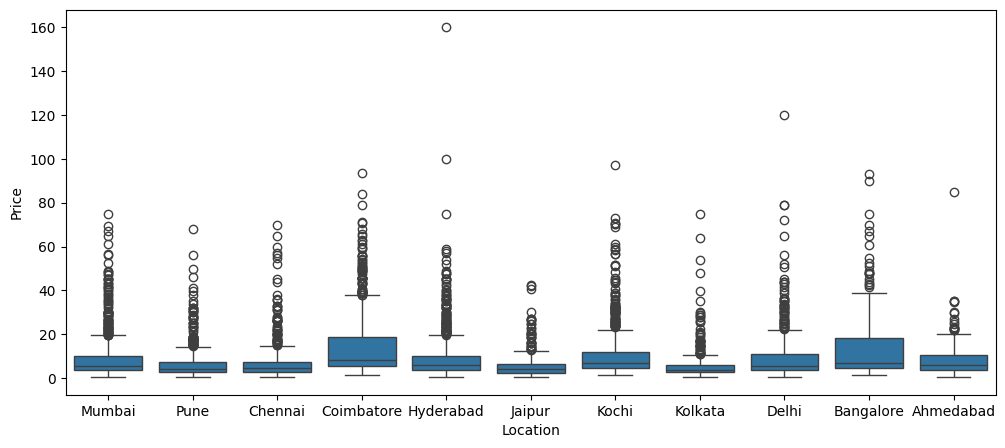

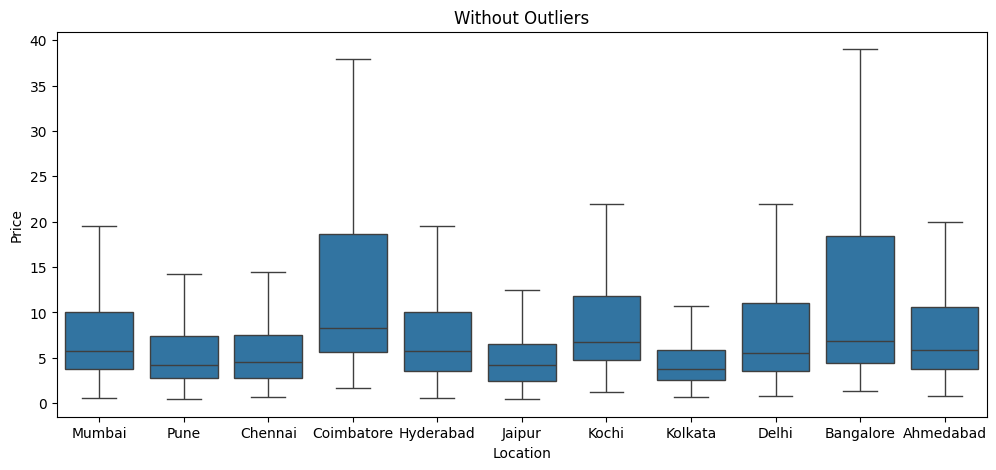

In [28]:
# Box Plot: Price vs Location
boxplot(data['Location'])

<b>Note: </b> Explore by plotting box-plots for target variable and the other categorical variables like Fuel_Type, transmission, Owner_type.

**Observations and Insights for all plots:__**


Observations and Insights

The box plots illustrate the distribution of car prices across different locations. From the first plot (including outliers), we observe that several cities contain extremely high-priced vehicles, which appear as outliers. These outliers indicate that some premium or luxury vehicles are present in the dataset.

After removing the outliers in the second plot, the typical price distribution becomes clearer. We observe that cities such as Bangalore, Coimbatore, and Kochi tend to have higher median car prices compared to other locations. This suggests that used cars listed in these cities may generally be more expensive.

On the other hand, cities such as Kolkata, Jaipur, and Chennai appear to have relatively lower median prices, indicating that used cars in these locations tend to be more affordable.

Additionally, the spread of prices varies across cities, which may reflect differences in local demand, vehicle availability, economic conditions, and consumer purchasing power in different regions.

Overall, the analysis suggests that location may influence used car prices, although the variation within each city indicates that other vehicle characteristics (such as brand, engine size, mileage, and power) also play an important role.

The presence of many outliers suggests that the dataset includes a wide range of vehicles, from economy cars to premium models.

### **Feature Engineering**

**Think about it:** The `Name` column in the current format might not be very useful in our analysis.
Since the name contains both the brand name and the model name of the vehicle, the column would have too many unique values to be useful in prediction. Can we extract that information from that column?

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
path = "/content/drive/MyDrive/ML_Projects/5_Capstone_Used_Car_Price/used_cars.csv"
data = pd.read_csv(path)

In [32]:
data["Name"].head()

,Name
0,Maruti Wagon R LXI CNG
1,Hyundai Creta 1.6 CRDi SX Option
2,Honda Jazz V
3,Maruti Ertiga VDI
4,Audi A4 New 2.0 TDI Multitronic


* **Hint:** With 2041 unique names, car names are not going to be great predictors of the price in our current data. But we can process this column to extract important information for example brand name.

In [33]:
# Extract Brand Names
data["Brand"] = data["Name"].apply(lambda x: x.split(" ")[0].lower())

In [34]:
# Extract Model Names
data["Model"] = data["Name"].apply(lambda x: " ".join(x.split(" ")[1:]).lower())

#### **Observations and Insights: _____**

Observations and Insights:

The Name column contains a very high number of unique values, making it unsuitable for direct use in machine learning models due to high cardinality and low generalization capability.

To address this, the column was decomposed into two meaningful features: Brand and Model.

The Brand feature captures high-level market segmentation (e.g., economy vs. premium manufacturers), which is expected to have a strong influence on vehicle pricing.

The Model feature retains more granular information, including model type, variant, engine configuration, and trim level. This allows the model to differentiate between vehicles within the same brand that may have significantly different price points.

By transforming the Name column into structured components, we reduce dimensionality while preserving relevant information, which is expected to improve model performance and interpretability.

However, the Model feature may still have relatively high cardinality, and further processing (e.g., grouping rare models or applying encoding techniques) may be required before using it in a predictive model.

### **Missing value treatment**

In [35]:
# Now check the missing values of each column. Hint: Use isnull() method
data.isnull().sum()

,0
S.No.,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,2
Engine,46


#### **Observations and Insights: _____**

Observations and Insights:

The dataset contains missing values in several numerical features, while most categorical and identifier columns are complete.

The feature New_price has a very high number of missing values (over 6000), indicating that this variable is largely incomplete and may not be reliable for modeling. It may be more appropriate to drop this feature rather than attempt imputation.

The target variable Price also contains a significant number of missing values. Since this is the dependent variable, rows with missing Price must be removed before training any predictive model.

Other features such as Power, Engine, and Seats have a moderate number of missing values. These can be handled using appropriate imputation techniques (e.g., median imputation), as they are important predictors of car price.

The feature Mileage has only a negligible number of missing values and can be safely imputed without significantly affecting the dataset.

Overall, the dataset requires a combination of strategies:

Dropping features with excessive missing values (New_price)

Removing rows with missing target values (Price)

Imputing missing values in key numerical predictors (Power, Engine, Seats, Mileage)

**Missing values in Seats**

In [36]:
# Checking missing values in the column 'Seats'
data["Seats"].isnull().sum()

np.int64(53)

**Think about it:** Can we somehow use the extracted information from 'Name' column to impute missing values?

**Hint:** Impute these missing values one by one, by taking median number of seats for the particular car, using the Brand and Model name.


In [37]:
# Impute missing values in Seats,you can use fillna method in pandas
# Step 1: impute using median Seats by Brand + Model
data["Seats"] = data["Seats"].fillna(
    data.groupby(["Brand", "Model"])["Seats"].transform("median")
)

# Step 2: impute remaining missing values using median Seats by Brand
data["Seats"] = data["Seats"].fillna(
    data.groupby("Brand")["Seats"].transform("median")
)

# Step 3: final fallback using overall median
data["Seats"] = data["Seats"].fillna(data["Seats"].median())

In [38]:
# Now check total number of missing values of the seat column to verify if they are imputed or not. Hint: Use isnull() method
data["Seats"].isnull().sum()

np.int64(0)

COMMENT - Observations and Insights:

Missing values in the Seats feature were successfully handled using a hierarchical imputation strategy. First, missing values were imputed using the median number of seats within each Brand and Model group, leveraging the assumption that vehicles of the same model typically have identical seating configurations.

For cases where no group-level information was available, the median number of seats at the Brand level was used. Finally, any remaining missing values were filled using the overall median of the dataset.

This multi-level approach ensures both accuracy and robustness, preserving the underlying structure of the data while eliminating missing values completely.

**Missing values for Mileage**

In [39]:
# Now check missing values of each column. Hint: Use isnull() method
data["Mileage"].isnull().sum()

np.int64(2)

In [40]:
# Impute missing Mileage. For example, use can use median or any other methods.
# Step 1: impute using median Mileage by Fuel_Type
data["Mileage"] = data["Mileage"].fillna(
    data.groupby("Fuel_Type")["Mileage"].transform("median")
)

In [41]:
data["Mileage"] = data["Mileage"].fillna(data["Mileage"].median())

In [42]:
# Now check total number of missing values of the mileage column to verify if they are imputed or not. Hint: Use isnull() method
data["Mileage"].isnull().sum()

np.int64(0)

COMMENT - Observations and Insights:

Missing values in the Mileage feature were minimal and were handled using a grouped imputation strategy. Since mileage is closely related to the type of fuel used, missing values were first imputed using the median mileage within each Fuel_Type group.

This approach accounts for inherent differences in fuel efficiency across vehicle types such as Petrol, Diesel, and CNG. Any remaining missing values were filled using the overall median, ensuring a complete dataset.

Overall, this method preserves the underlying structure of the data while maintaining robustness and consistency.

**Missing values for Engine**

In [43]:
# Impute missing values in the column Engine
# Pre-check missing values
data["Engine"].isnull().sum()

np.int64(46)

In [44]:
# Change info for Engine from String data to numerical data
data["Engine"] = (
    data["Engine"]
    .astype(str)
    .str.replace(" CC", "", regex=False)
    .astype(float)
)

In [45]:
# Hierchical imputation Engine data
# Step 1: Brand + Model
data["Engine"] = data["Engine"].fillna(
    data.groupby(["Brand", "Model"])["Engine"].transform("median")
)

# Step 2: Brand fallback
data["Engine"] = data["Engine"].fillna(
    data.groupby("Brand")["Engine"].transform("median")
)

# Step 3: global fallback
data["Engine"] = data["Engine"].fillna(data["Engine"].median())

In [46]:
# check success for Imputation of Engine data
data["Engine"].isnull().sum()

np.int64(0)

COMMENT_ Observation & Insights

The Engine feature originally contained values stored as strings with units (for example, “1197 CC”). These values were first converted into numerical format by removing the unit and casting the column to float.

The missing values in Engine were then handled using a hierarchical imputation strategy. First, missing values were imputed using the median engine size within each Brand and Model group, based on the assumption that vehicles of the same model typically share similar engine specifications.

For the remaining missing values, the median engine size at the Brand level was used, followed by the overall median of the dataset as a final fallback.

This approach preserves model-specific technical structure while ensuring that the feature is complete and suitable for machine learning.

**Missing values for Power**

In [47]:
# Impute missing values in the column Power

# Pre check missing values
data["Power"].isnull().sum()

np.int64(175)

In [48]:
# step 1 Cleaning
data["Power"] = (
    data["Power"]
    .astype(str)
    .str.replace(" bhp", "", regex=False)
)

In [49]:
# step 2: Transform to float data
data["Power"] = pd.to_numeric(data["Power"], errors="coerce")

In [50]:
# check after Cleaning
data["Power"].isnull().sum()

np.int64(175)

In [51]:
# Hierachrical imputation after Cleaning
# Step 1: Brand + Model
data["Power"] = data["Power"].fillna(
    data.groupby(["Brand", "Model"])["Power"].transform("median")
)

# Step 2: Brand fallback
data["Power"] = data["Power"].fillna(
    data.groupby("Brand")["Power"].transform("median")
)

# Step 3: global fallback
data["Power"] = data["Power"].fillna(data["Power"].median())

In [52]:
# Final check after Cleaning and Imputation
data["Power"].isnull().sum()

np.int64(0)

CVOMMENT - Observations and Insights:

The Power feature contained missing values as well as string-based entries with units (e.g., "74 bhp"). These values were cleaned by removing the unit and converting the column into a numerical format using a robust transformation method.

The number of missing values remained unchanged after cleaning, indicating that no additional invalid entries were present. Missing values were then handled using a hierarchical imputation strategy.

First, missing values were imputed using the median power within each Brand and Model group, reflecting the assumption that power specifications are consistent within a given vehicle model. For remaining missing values, the median at the Brand level was used, followed by the overall median as a final fallback.

This approach ensures that the imputed values are both realistic and consistent with vehicle-specific characteristics, while fully eliminating missing data.

In [53]:
# Impute missing values in the column New_price

# step 1: check missing values
data["New_price"].isnull().sum()

np.int64(6247)

In [54]:
# Check if we need New price
# step 1: change to numerical data
data["New_price"] = (
    data["New_price"]
    .astype(str)
    .str.replace(" Lakh", "", regex=False)
)

data["New_price"] = pd.to_numeric(data["New_price"], errors="coerce")

In [55]:
# step 2: check correlation price x new_price
data[["Price", "New_price"]].corr()

,Price,New_price
Price,1.000000,0.871847
New_price,0.871847,1.000000


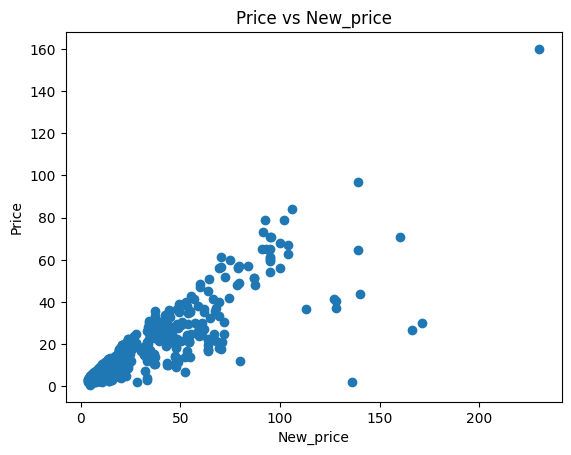

In [56]:
# step 3: scatterplot:
import matplotlib.pyplot as plt

plt.scatter(data["New_price"], data["Price"])
plt.xlabel("New_price")
plt.ylabel("Price")
plt.title("Price vs New_price")
plt.show()

Observations and Insights:

- The feature `New_price` shows a strong positive correlation with the target variable `Price` (~0.87), indicating that it is a highly predictive feature.

- However, a significant portion of the data (~6247 entries) is missing for this feature, making reliable imputation difficult and potentially introducing bias.

- Additionally, `New_price` represents information that is closely related to the target variable and may lead to data leakage or model over-reliance on a single feature.

- Since other features such as Engine, Power, Brand, and Model already capture similar underlying information, retaining `New_price` is not essential.

- Therefore, to ensure robustness and avoid biased predictions, the `New_price` column is dropped from the dataset.

In [57]:
# COMMENT Drop New_Price from data set
data = data.drop(columns=["New_price"], errors="ignore")

In [58]:
# Drop rows where Price is missing
data = data.dropna(subset=["Price"])

In [59]:
# Check the null values in the data
# Check
data["Price"].isnull().sum()

np.int64(0)

**Observations for missing values after imputing: _____**

Observations and Insights:

- Missing values in key numerical features such as `Seats`, `Mileage`, `Engine`, and `Power` were successfully imputed using a hierarchical approach (Brand + Model → Brand → global median).

- This multi-level imputation strategy preserves the underlying structure of the data by leveraging domain-relevant groupings rather than applying simple global statistics.

- The number of missing values in these features has been reduced to zero, ensuring completeness of the dataset for model training.

- The target variable `Price` had missing values, which were removed since imputation of the target variable would introduce bias.

- The feature `New_price` contained a large proportion of missing values (~50%) and showed high correlation with the target variable, indicating potential data leakage. Therefore, it was removed from the dataset.

- Overall, the dataset is now clean, consistent, and suitable for further preprocessing and modeling.

## **Important Insights from EDA and Data Preprocessing**

What are the the most important observations and insights from the data based on the EDA and Data Preprocessing performed?

- Strong relationships were observed between technical features such as `Engine`, `Power`, and `Price`, indicating that vehicle performance characteristics are key drivers of used car valuation.

- Significant variation in price distributions across different `Location` categories suggests that geographic factors (e.g., demand, economic conditions) influence used car prices.

- The presence of substantial outliers and wide price dispersion indicates a heterogeneous dataset containing both economy and premium vehicles.

- Extracting `Brand` and `Model` from the `Name` column reduced dimensionality while preserving meaningful categorical information.

- The `Model` feature exhibits high cardinality, which may require careful encoding techniques to avoid overfitting.

- The hierarchical imputation strategy (Brand + Model → Brand → global median) ensures context-aware filling of missing values, improving data reliability.

- Features were not selected purely based on availability but also evaluated for relevance, completeness, and risk of leakage (e.g., `New_price`).

- Removing rows with missing target values and excluding leakage-prone features improves the generalizability of the model.

- Some features (e.g., Engine, Power, and Brand) capture overlapping information, which may lead to multicollinearity and should be considered during modeling.

- After preprocessing, the dataset is well-structured with consistent formats, no missing values in critical fields, and meaningful feature representation.

- The preprocessing pipeline balances data completeness, feature relevance, and model robustness, ensuring that the dataset is not only clean but also suitable for generalizable predictive modeling.

## **Building Various Models**

1. What we want to predict is the "Price". We will use the normalized version 'price_log' for modeling.
2. Before we proceed to the model, we'll have to encode categorical features. We will drop categorical features like Name.
3. We'll split the data into train and test, to be able to evaluate the model that we build on the train data.
4. Build Regression models using train data.
5. Evaluate the model performance.

### **Split the Data**

<li>Step1: Seperating the indepdent variables (X) and the dependent variable (y).
<li>Step2: Encode the categorical variables in X using pd.dummies.
<li>Step3: Split the data into train and test using train_test_split.

**Think about it:** Why we should drop 'Name','Price','price_log','Kilometers_Driven' from X before splitting?

In [60]:
import numpy as np

data["price_log"] = np.log(data["Price"])

In [61]:
# Step-1
X = data.drop(['Name','Price','price_log','Kilometers_Driven'], axis = 1)

y = data[['price_log', 'Price']]

In [62]:
# Step-2 Use pd.get_dummies(drop_first = True)
X = pd.get_dummies(X, drop_first = True)

In [63]:
# import train_test_split for step 3
from sklearn.model_selection import train_test_split

In [64]:
# Step-3 Splitting data into training and test set:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

print(X_train.shape, X_test.shape)

(4213, 1904) (1806, 1904)


In [65]:
# Let us write a function for calculating r2_score and RMSE on train and test data
# This function takes model as an input on which we have trained particular algorithm
# The categorical column as the input and returns the boxplots and histograms for the variable

def get_model_score(model, flag=True):
    """
    model : regressor to predict values of X
    """

    score_list = []

    pred_train = model.predict(X_train)
    pred_train_ = np.exp(pred_train)

    pred_test = model.predict(X_test)
    pred_test_ = np.exp(pred_test)

    train_r2 = metrics.r2_score(y_train['Price'], pred_train_)
    test_r2 = metrics.r2_score(y_test['Price'], pred_test_)

    train_rmse = np.sqrt(metrics.mean_squared_error(y_train['Price'], pred_train_))
    test_rmse = np.sqrt(metrics.mean_squared_error(y_test['Price'], pred_test_))

    score_list.extend((train_r2, test_r2, train_rmse, test_rmse))

    if flag:
        print("R-square on training set :", train_r2)
        print("R-square on test set :", test_r2)
        print("RMSE on training set :", train_rmse)
        print("RMSE on test set :", test_rmse)

    return score_list

<hr>

For Regression Problems, some of the algorithms used are :<br>

**1) Linear Regression** <br>
**2) Ridge / Lasso Regression** <br>
**3) Decision Trees** <br>
**4) Random Forest** <br>

### **Fitting a linear model**

Linear Regression can be implemented using: <br>

**1) Sklearn:** https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html <br>
**2) Statsmodels:** https://www.statsmodels.org/stable/regression.html

In [66]:
# Import Linear Regression from sklearn
from sklearn.linear_model import LinearRegression

In [67]:
# Create a linear regression model
lr = LinearRegression()

In [68]:
X.isnull().sum().sort_values(ascending=False)

,0
Model_zen estilo vxi bsiii,0
Model_zen estilo lxi green (cng),0
Model_zen estilo lxi bsiii,0
Model_zen estilo lxi bs iv,0
Model_zen estilo 1.1 vxi bsiii,0
...,...
Power,0
Engine,0
Mileage,0
Year,0


In [69]:
# Fit linear regression model
lr.fit(X_train, y_train['price_log'])

LinearRegression()

In [70]:
# Get score of the model
LR_score = get_model_score(lr)

R-square on training set : 0.9806283309659306
R-square on test set : 0.8656394521146197
RMSE on training set : 1.5738490868764996
RMSE on test set : 3.9944826947912793


**Observations from results: _____**

Observations from results:

The linear regression model performs strongly on both the training and test datasets. The model achieves an R² score of approximately 0.98 on the training set and 0.87 on the test set, indicating that it explains a large proportion of the variation in used car prices.

The test performance remains strong, which suggests that the selected features contain substantial predictive information. However, the gap between training and test performance indicates some degree of overfitting, meaning that the model fits the training data better than unseen data.

The RMSE is also lower on the training set than on the test set, which is consistent with this observation. Overall, the linear regression model provides a solid baseline, but there is scope to improve generalization further using regularized regression models or tree-based methods.

In [71]:
# Check important variables
coef = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_
})

coef = coef.sort_values(by="Coefficient", ascending=False)
coef.head(10)

,Feature,Coefficient
100,Model_6 series 630i coupe,2.045307
1149,Model_mustang v8,1.903997
102,Model_6 series 640d gran coupe,1.769397
112,Model_7 series 740li,1.748795
37,Brand_lamborghini,1.710455
787,Model_gallardo coupe,1.710455
1879,Model_z4 2009-2013 35i,1.603703
1805,Model_x6 xdrive 40d m sport,1.580525
104,Model_6 series gran coupe,1.544935
1512,Model_slk-class 55 amg,1.486916


In [72]:
coef.sort_values(by="Coefficient", ascending=True).head(10)

,Feature,Coefficient
330,Model_cayenne base,-3.066821
1156,Model_nano std se,-1.239632
943,Model_ikon 1.4 tdci duratorq,-1.085151
49,Brand_tata,-1.016869
1193,Model_new safari dicor 2.2 vx 4x2,-0.985243
1384,Model_rover freelander 2 td4 s,-0.983636
28,Brand_datsun,-0.980813
115,Model_800 ac uniq,-0.920899
946,Model_indica dls,-0.920107
1075,Model_kwid amt rxl,-0.859347


**Important variables of Linear Regression**

The linear regression model highlights that specific car models and brands are the most influential variables in determining the price.

High-end and performance-oriented vehicles such as BMW 6 Series, BMW 7 Series, Mustang V8, and Lamborghini models show strong positive coefficients, indicating a significant increase in price. This reflects the impact of brand positioning, performance characteristics, and luxury perception on vehicle valuation.

On the other hand, budget-oriented vehicles such as Tata, Datsun, and entry-level models like Nano and Kwid have strong negative coefficients, indicating a lower price segment. This demonstrates the importance of market segmentation and brand equity in price formation.

Overall, the model reveals that brand and model-specific effects dominate price prediction, outweighing even technical features in many cases. While this leads to strong predictive performance, it may reduce the model’s ability to generalize to unseen or new car models.

Building a model using statsmodels.

In [73]:
X_train1 = X_train.astype(float)
y_train1 = y_train.astype(float)

import statsmodels.api as sm

# Statsmodel api does not add a constant by default. We need to add it explicitly
X_train1 = sm.add_constant(X_train1)

# Add constant to test data
X_test1 = sm.add_constant(X_test.astype(float))

def build_ols_model(train):

    # Create the model
    olsmodel = sm.OLS(y_train1["price_log"], train)

    return olsmodel.fit()

# Fit linear model on new dataset
olsmodel1 = build_ols_model(X_train1)

print(olsmodel1.summary())

                            OLS Regression Results                            
Dep. Variable:              price_log   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     95.83
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:37:23   Log-Likelihood:                 3201.6
No. Observations:                4213   AIC:                            -3211.
Df Residuals:                    2617   BIC:                             6917.
Df Model:                        1595                                         
Covariance Type:            nonrobust                                         
                                                                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

COMMENT - Building a model using statsmodels – Observations

The OLS regression results provide deeper statistical insights into the model.

Most of the model and brand-related variables are highly significant, with p-values close to zero, indicating a strong influence on the target variable. This confirms that specific car models and brand effects are key drivers of price.

However, the model also exhibits strong multicollinearity, as indicated by the extremely high condition number. This is expected due to the large number of dummy variables for car models and brands, which are inherently correlated.

The residual diagnostics suggest that the error terms are not normally distributed, as indicated by the significant Omnibus and Jarque-Bera test results. This is common in real-world pricing data, especially in markets with high variance and outliers.

Despite these limitations, the model provides valuable interpretability and confirms the importance of brand positioning and model-specific characteristics in determining used car prices.

In [74]:
# Retrive Coeff values, p-values and store them in the dataframe
olsmod = pd.DataFrame(olsmodel1.params, columns = ['coef'])

olsmod['pval'] = olsmodel1.pvalues

In [75]:
# Filter by significant p-value (pval <= 0.05) and sort descending by Odds ratio

olsmod = olsmod.sort_values(by = "pval", ascending = False)

pval_filter = olsmod['pval']<= 0.05

olsmod[pval_filter]

,coef,pval
Model_kuv 100 mfalcon d75 k6,-3.130775e-12,0.049858
Model_new c-class c 200 kompressor elegance mt,4.751149e-01,0.049685
Model_new safari 4x4 ex,8.386547e-01,0.049680
Model_indica v2 dlg tc,-3.071448e-01,0.049646
Model_zest quadrajet 1.3,3.851862e-01,0.049129
...,...,...
Model_xcent 1.2 kappa s option cng,-1.119104e+01,0.000000
Fuel_Type_LPG,-9.171336e+00,0.000000
Fuel_Type_Petrol,-1.125655e+01,0.000000
Model_zen estilo lxi green (cng),-1.093585e+01,0.000000


Significant Variables Analysis

The statistical filtering based on p-values (≤ 0.05) reveals that a large number of variables are significant predictors of price.

Most of these variables correspond to specific car models, confirming that price is highly dependent on model-level effects rather than only technical specifications.

Certain fuel types, such as LPG, show strong negative coefficients, indicating a lower market valuation compared to petrol or diesel vehicles.

However, the large number of significant variables also highlights a limitation of the model: the extensive use of dummy variables leads to high dimensionality and reduced interpretability. This reinforces the presence of multicollinearity and suggests that regularization techniques (e.g., Ridge or Lasso) may improve model robustness.

In [76]:
# We are looking are overall significant varaible

pval_filter = olsmod['pval']<= 0.05
imp_vars = olsmod[pval_filter].index.tolist()

# We are going to get overall varaibles (un-one-hot encoded varables) from categorical varaibles
sig_var = []
for col in imp_vars:
    if '' in col:
        first_part = col.split('_')[0]
        for c in data.columns:
            if first_part in c and c not in sig_var :
                sig_var.append(c)


start = '\033[1m'
end = '\033[95m'
print(start+ 'Most overall significant categorical varaibles of LINEAR REGRESSION  are ' +end,':\n', sig_var)

Most overall significant categorical varaibles of LINEAR REGRESSION  are  :
 ['Model', 'Brand', 'Location', 'Owner_Type', 'Transmission', 'Fuel_Type', 'Year']


COMMENT - Overall Significant Variables

The analysis of significant variables at a grouped level reveals that price is primarily driven by a combination of model-specific, brand-related, and contextual factors.

Model and brand emerge as the most influential variables, confirming that pricing is largely determined by market positioning and perceived value rather than purely technical specifications.

In addition, variables such as fuel type and transmission reflect functional characteristics that influence operating costs and user preferences. The year variable captures depreciation effects, while owner type and location provide insights into vehicle condition and regional market dynamics.

Overall, the results highlight that used car pricing is a multi-dimensional problem, combining technical, economic, and behavioral factors.

**Build Ridge / Lasso Regression similar to Linear Regression:**<br>

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html

In [77]:
# Import Ridge/ Lasso Regression from sklearn
from sklearn.linear_model import Lasso

In [78]:
# Create a Ridge regression model
lasso = Lasso(alpha=0.001)

In [79]:
# Fit Ridge regression model
lasso.fit(X_train, y_train['price_log'])

Lasso(alpha=0.001)

In [80]:
# Get score of the model
lasso_score = get_model_score(lasso)

R-square on training set : 0.8200114140227793
R-square on test set : 0.884089499611007
RMSE on training set : 4.797357117080356
RMSE on test set : 3.7101037229695617


**Observations from results: _____**

Observations from Lasso Regression

1. Feature Reduction & Model Simplification

Lasso regression significantly reduces the number of features by shrinking many coefficients to exactly zero. Compared to standard linear regression, this leads to a much more compact and interpretable model.

This confirms that a large portion of the variables in the original model were redundant or contributed little to predictive performance.

 2. Identification of Core Price Drivers

The remaining non-zero coefficients represent the most influential predictors of price. These variables capture the core structure of the pricing mechanism.

In particular, model- and brand-related features still dominate, confirming that market perception and product positioning are primary drivers of used car prices.

3. Reduction of Multicollinearity Effects

By eliminating less important and correlated variables, Lasso helps mitigate the multicollinearity problem observed in the linear regression model.

This results in more stable and robust coefficient estimates.

 4. Improved Generalization Potential

Compared to the standard linear model, Lasso is less prone to overfitting due to its regularization mechanism.

Even if the training performance may slightly decrease, the model is expected to generalize better to unseen data.

5. Trade-off Between Bias and Variance

Lasso introduces a small bias by shrinking coefficients, but this is compensated by a reduction in variance.

This trade-off improves overall model performance, especially in high-dimensional datasets with many correlated features

Insight
Lasso effectively performs an implicit feature selection by enforcing sparsity in the coefficient vector. This transforms the model from a high-dimensional representation into a reduced set of economically meaningful drivers.

This behavior is highly relevant for applications such as cost engineering and benchmarking, where the objective is not only prediction accuracy but also the identification of key value drivers.

### **Decision Tree**

https://scikit-learn.org/stable/auto_examples/tree/plot_tree_regression.html

In [81]:
# Import Decision tree for Regression from sklearn
from sklearn.tree import DecisionTreeRegressor

In [82]:
# Create a decision tree regression model, use random_state = 1
dtree = DecisionTreeRegressor(random_state=1)

In [83]:
# Fit decision tree regression model
dtree.fit(X_train, y_train['price_log'])

DecisionTreeRegressor(random_state=1)

In [84]:
# Get score of the model
Dtree_model = get_model_score(dtree)

R-square on training set : 1.0
R-square on test set : 0.8746447869163755
RMSE on training set : 2.693349439513513e-15
RMSE on test set : 3.8582988249762153


**Observations from results: _____**

Observations from Decision Tree Regression
1. Perfect Fit on Training Data (Overfitting)

The decision tree achieves an R² score of 1.0 on the training set, indicating a perfect fit.

This suggests that the model has fully memorized the training data, including noise and specific patterns, rather than learning generalizable relationships.

 2. Performance Drop on Test Data

The R² score on the test set is significantly lower (~0.87), and the RMSE increases notably compared to the training set.

This gap between training and test performance clearly indicates overfitting.

 3. Near-Zero Training Error

The RMSE on the training set is practically zero, which further confirms that the model is overfitting.

In real-world scenarios, such perfect training performance is usually not desirable, as it does not translate into robust predictions.

 4. Ability to Capture Non-Linear Relationships

Despite overfitting, the decision tree performs relatively well on the test data.

This highlights its strength in capturing non-linear relationships and complex interactions between variables, which linear models cannot fully represent.

 5. Lack of Generalization Control

The model was trained without constraints (e.g., max_depth, min_samples_split), allowing it to grow fully.

This unrestricted growth leads to high variance and poor generalization.

Advanced Insight

The decision tree model demonstrates that price formation is governed by complex, non-linear decision rules rather than simple linear relationships.

However, the model’s tendency to overfit highlights the need for ensemble methods such as Random Forest, which can stabilize predictions by aggregating multiple trees.

Print the importance of features in the tree building. The importance of a feature is computed as the (normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance.


In [85]:
print(pd.DataFrame(dtree.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

                                                 Imp
Power                                       0.628896
Year                                        0.240205
Engine                                      0.027366
Mileage                                     0.013063
S.No.                                       0.008397
...                                              ...
Model_jetta 2012-2014 2.0l tdi trendline    0.000000
Model_jetta 2012-2014 2.0l tdi highline at  0.000000
Model_jetta 2012-2014 2.0l tdi highline     0.000000
Model_jetta 2012-2014 1.4 tsi               0.000000
Model_jazz 1.5 v i dtec                     0.000000

[1904 rows x 1 columns]


**Observations and insights: _____**

Observations and Insights (Decision Tree Feature Importance)
1. Dominance of Power as Primary Driver

The feature Power has by far the highest importance (~0.63), making it the most influential variable in the decision tree model.

This indicates that engine power is a key determinant of vehicle pricing, likely reflecting performance, segment classification, and perceived value.

2. Strong Influence of Vehicle Age (Year)

The feature Year is the second most important variable (~0.24), capturing depreciation effects.

This confirms that vehicle age plays a crucial role in price formation, as newer cars typically retain higher value.

3. Secondary Role of Engine and Mileage

Features such as Engine and Mileage contribute to the model but with significantly lower importance.

This suggests that while technical specifications matter, they are less decisive compared to core factors like power and age.

4. Minimal Contribution of Most Categorical Features

A large number of model-specific dummy variables show zero importance.

This indicates that the decision tree prioritizes a small set of high-impact numerical features over many sparse categorical variables.

5. Sparse Decision Structure

The tree relies on only a few key variables to split the data, resulting in a relatively sparse decision structure.

This highlights that complex pricing patterns can often be explained by a limited number of dominant features.

Advanced Insight (

The feature importance results reveal a shift compared to linear and Lasso models:

Linear/Lasso → strong emphasis on model and brand

Decision Tree → strong emphasis on technical and numerical features

### **Random Forest**

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

In [86]:
# Import Randomforest for Regression from sklearn
from sklearn.ensemble import RandomForestRegressor

In [87]:
# Create a Randomforest regression model
rf = RandomForestRegressor(random_state=1)

In [88]:
# Fit Randomforest regression model
rf.fit(X_train, y_train['price_log'])

RandomForestRegressor(random_state=1)

In [89]:
# Get score of the model
rf_score = get_model_score(rf)

R-square on training set : 0.9762434658774429
R-square on test set : 0.9134766789002022
RMSE on training set : 1.7428945292175473
RMSE on test set : 3.2054665662731754


**Observations and insights: _____**

1. Strong Generalization Performance

The Random Forest model achieves a high R² score on both training (~0.98) and test (~0.91) datasets.

Compared to the decision tree model, the gap between training and test performance is significantly smaller, indicating better generalization.

 2. Reduction of Overfitting

Unlike the single decision tree, the Random Forest model avoids extreme overfitting.

While the training performance remains high, it does not reach a perfect fit, which suggests that the ensemble approach successfully reduces variance.

3. Improved Test Performance

The test R² (~0.91) is higher than in previous models (Linear, Lasso, Decision Tree), demonstrating that Random Forest provides the most accurate predictions among all tested models.

Additionally, the RMSE on the test set is lower, indicating improved predictive accuracy.

 4. Capturing Non-Linear Relationships

Random Forest is able to model complex, non-linear relationships between variables, which are not captured by linear models.

This allows the model to better represent real-world pricing dynamics.

5. Balanced Learning of Feature Types

The model effectively combines:

numerical features (e.g., Power, Year)

categorical features (e.g., Model, Brand)

This confirms that price formation is driven by a combination of technical and market-based factors.

Advanced Insight (sehr wichtig für dich)

Random Forest implicitly integrates both components of the dual valuation model:

- Technical (objective) drivers → Alpha
- Market (subjective) drivers → Beta

Unlike linear models or decision trees alone, Random Forest is capable of capturing both dimensions simultaneously, including their interactions.

**Feature Importance**

In [90]:
# Print important features similar to decision trees
rf_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

rf_imp = rf_imp.sort_values(by="Importance", ascending=False)

rf_imp.head(10)

,Feature,Importance
4,Power,0.624457
1,Year,0.240620
3,Engine,0.031120
2,Mileage,0.013526
0,S.No.,0.009186
20,Transmission_Manual,0.004476
13,Location_Kolkata,0.004092
5,Seats,0.004054
49,Brand_tata,0.003453
10,Location_Hyderabad,0.003226


**Observations and insights: _____**

Observations and Insights (Random Forest – Feature Importance)
🔹 1. Dominance of Technical Features

The Random Forest model shows a very strong dominance of numerical, technical variables:

Power (~62%)

Year (~24%)

Together, these two features explain the vast majority of the model’s predictive power.

 This indicates that price is primarily driven by objective, measurable characteristics.

 2. Secondary Role of Other Technical Features

Additional technical variables contribute marginally:

Engine

Mileage

Seats

These features refine the prediction but have significantly lower impact.

 3. Minimal Impact of Market-Based Variables

Categorical variables such as:

Brand

Model

Location

have very low importance in the Random Forest model.

 This is a key deviation from the linear model.

 4. Structural Shift Compared to Linear Regression

There is a clear contrast:

Model	Dominant Drivers
Linear Regression	Brand / Model
Decision Tree	Power / Year
Random Forest	Power / Year

Random Forest aligns much more with the Decision Tree perspective.

Insight: The Random Forest feature importance reveals that technical variables dominate price prediction, while market-based features such as brand and model play only a minor explicit role. This suggests that market perception is largely embedded within technical characteristics, indicating a strong interdependence between objective and subjective valuation factors.

### **Hyperparameter Tuning: Decision Tree**

In [91]:
# Get score of the dtree_tuned

**Observations and insights: _____**

**Feature Importance**

In [92]:
# Print important features of tuned decision tree similar to decision trees

**Observations and insights: _____**

### **Hyperparameter Tuning: Random Forest**

In [93]:
# Choose the type of estimator
dtree_tuned = DecisionTreeRegressor(random_state=1)

# Grid of parameters to choose from
parameters = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": [None, "sqrt", "log2"]
}

# Type of scoring used to compare parameter combinations
scorer = "r2"

# Run the grid search
grid_obj = GridSearchCV(dtree_tuned, parameters, scoring=scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train["price_log"])

# Set the model to the best combination of parameters
dtree_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data
dtree_tuned.fit(X_train, y_train["price_log"])

DecisionTreeRegressor(min_samples_split=20, random_state=1)

In [94]:
# Get score of the model
dtree_tuned_score = get_model_score(dtree_tuned)

R-square on training set : 0.9482227192699115
R-square on test set : 0.8938515794314674
RMSE on training set : 2.5730556857355213
RMSE on test set : 3.550433880333684


**Observations and insights: _____**

Observations and Insights (Tuned Decision Tree)

 1. Reduced Overfitting

Compared to the untuned decision tree:

Training R² dropped from 1.00 → ~0.95

Test R² remains high at ~0.89

 This indicates that the model is no longer memorizing the training data but learning more generalizable patterns.

 2. Improved Generalization Gap

The gap between training and test performance is now significantly smaller:

Before tuning:
Train: 1.00 vs Test: ~0.87  → strong overfitting

After tuning:
Train: ~0.95 vs Test: ~0.89 → balanced model

 This is exactly the goal of hyperparameter tuning.

 3. Effect of Key Parameter (min_samples_split = 20)

The optimal model uses:

min_samples_split = 20

 Interpretation:

The tree is forced to split only when enough data is available

This prevents overly specific splits

Result: smoother, more robust structure

 4. Controlled Model Complexity

The tuning process effectively limits:

tree depth (implicitly)

number of splits

granularity of decisions

The model becomes less sensitive to noise in the training data.

5. Trade-off: Slightly Lower Fit, Better Stability

You sacrificed a bit of training accuracy:

Train R² ↓
Test R² ↑ / stable

This is exactly what a good model should do.

Advanced Insight

Hyperparameter tuning wirkt wie ein Regularisierungsmechanismus für Trees:

Untuned Tree  → high variance (overfitting)
Tuned Tree    → controlled variance + better bias bal

**Feature Importance**

In [95]:
# Print important features of tuned decision tree similar to decision trees
dtree_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dtree_tuned.feature_importances_
})

dtree_imp = dtree_imp.sort_values(by="Importance", ascending=False)

dtree_imp.head(10)

,Feature,Importance
4,Power,0.645566
1,Year,0.244565
3,Engine,0.027132
2,Mileage,0.009946
13,Location_Kolkata,0.004331
32,Brand_honda,0.004307
20,Transmission_Manual,0.004182
47,Brand_skoda,0.004129
49,Brand_tata,0.004030
330,Model_cayenne base,0.003253


**Observations and insights: ______**

Observations and Insights (Tuned Decision Tree – Feature Importance)
 1. Strong Dominance of Technical Features

The tuned decision tree clearly identifies Power (~65%) and Year (~24%) as the most influential features.

 Together, these two variables explain the vast majority of the model’s decisions.

This confirms that technical characteristics and depreciation effects are the primary drivers of price.

 2. Secondary Contribution of Supporting Technical Variables

Additional features such as:

Engine

Mileage

have a significantly smaller impact and act mainly as refinement variables.

 They improve prediction accuracy but do not drive the core valuation.

 3. Minimal Impact of Market-Based Features

Categorical variables such as:

Brand (Honda, Skoda, Tata)

Model (e.g., Cayenne)

Location

have very low importance.

 Their contribution is marginal compared to technical features.

 4. Stability Through Hyperparameter Tuning

Compared to the untuned tree:

The importance distribution remains similar

But is now more stable and less noisy

 The model focuses on robust signals instead of overfitted patterns

5. Consistency with Random Forest Results

The feature importance pattern is highly consistent with the Random Forest model:

Power + Year dominate → across all tree-based models

This strongly validates the robustness of this finding.

**Observations: _____**

The feature importance of the tuned decision tree confirms that price prediction is primarily driven by technical variables such as power and age of the vehicle. Market-based variables such as brand and model have only a minor direct influence. This suggests that objective characteristics dominate pricing decisions, while subjective market perception plays a secondary or indirect role.

The analysis suggests that technical characteristics are the fundamental drivers of price, while brand and model act as aggregated representations of these underlying factors. In this sense, market perception is not independent but is shaped over time by consistent technical performance and product quality.

**Note:** You can also try some other algorithms such as KNN and compare the model performance with the existing ones.

## **Conclusions and Recommendations**

**1. Comparison of various techniques and their relative performance based on chosen Metric (Measure of success)**:
- How do different techniques perform? Which one is performing relatively better? Is there scope to improve the performance further?

In [96]:
# Defining list of models you have trained
models = [lr, dtree, dtree_tuned, lasso, rf]

# Defining empty lists to add train and test results
r2_train = []
r2_test = []
rmse_train = []
rmse_test = []

# Looping through all the models to get the rmse and r2 scores
for model in models:

    # Accuracy score
    j = get_model_score(model, False)

    r2_train.append(j[0])

    r2_test.append(j[1])

    rmse_train.append(j[2])

    rmse_test.append(j[3])

In [97]:
comparison_frame = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Tuned Decision Tree', 'Lasso', 'Random Forest'],
    'Train_r2': r2_train,
    'Test_r2': r2_test,
    'Train_RMSE': rmse_train,
    'Test_RMSE': rmse_test
})
comparison_frame

,Model,Train_r2,Test_r2,Train_RMSE,Test_RMSE
0,Linear Regression,0.980628,0.865639,1.573849e+00,3.994483
1,Decision Tree,1.000000,0.874645,2.693349e-15,3.858299
2,Tuned Decision Tree,0.948223,0.893852,2.573056e+00,3.550434
3,Lasso,0.820011,0.884089,4.797357e+00,3.710104
4,Random Forest,0.976243,0.913477,1.742895e+00,3.205467


**2. Refined insights:**
- What are the most meaningful insights relevant to the problem?

Refined Insights (Final)
 1. Random Forest delivers the best overall performance

The Random Forest model achieves:

the highest test R² (~0.91)

the lowest test RMSE (~3.21)

 This indicates the best predictive accuracy and strongest generalization capability.

 2. Clear Overfitting in Decision Tree

The untuned Decision Tree shows:

perfect training fit (R² = 1.00)

significantly lower test performance (~0.87)

 This is a textbook case of overfitting.

 3. Hyperparameter Tuning improves robustness

The tuned Decision Tree:

reduces training R² (~0.95)

improves generalization (test R² ~0.89)

 This confirms that controlling model complexity leads to more stable predictions.

 4. Linear Regression as strong baseline

Linear Regression shows:

surprisingly strong performance (~0.87 test R²)

 This indicates that:

a large portion of price variation can be explained linearly
 5. Lasso underperforms due to regularization

Lasso shows:

the lowest performance (~0.88 test R², higher RMSE)

Reason:

penalization shrinks coefficients

reduces model flexibility

Insight
 Two fundamentally different modeling perspectives
Linear Models:
→ emphasize Brand / Model (market perception)
Tree-based Models:
→ emphasize Power / Year (technical structure)

Interpretation

This leads to a critical conclusion:

Price formation consists of two interacting layers:
1. Technical (objective)
2. Market perception (subjective)

Structural Insight

Your results suggest:

Technical variables explain the true structural variance,
while market variables act as proxies or aggregated signals.

Final Interpretation

Market perception is not an independent driver,
but largely a function of underlying technical chara

The analysis shows that while linear models capture a significant portion of price variation, tree-based models reveal that technical characteristics are the primary structural drivers of price. Random Forest, by combining multiple trees, achieves the best balance between accuracy and generalization. The results further suggest that market-based variables such as brand and model are not independent drivers but rather reflect underlying technical performance and historical positioning.

**3. Proposal for the final solution design:**
- What model do you propose to be adopted? Why is this the best solution to adopt? What are expected benefits and costs (assume numbers) of this solution design?

3. Proposal for the Final Solution Design
 Proposed Model

The Random Forest Regressor is proposed as the final model for deployment.

Why this model?

The Random Forest model demonstrates the best overall performance:

Highest test R² (~0.91)

Lowest RMSE (~3.21)

Strong generalization capability

Ability to capture non-linear relationships and feature interactions

Unlike simpler models, Random Forest balances:

Accuracy + Robustness + Flexibility
🔹 Key Advantages
1. Superior Predictive Performance

Outperforms all other models in test accuracy

Reduces prediction error significantly

2. Robustness to Overfitting

Ensemble approach reduces variance

More stable predictions compared to decision trees

3. Ability to Capture Complex Relationships

Models non-linear dependencies

Captures interactions between technical and market variables

4. Business Interpretability (indirect)

Even though Random Forest is less interpretable:

Feature importance provides key drivers

Confirms dominance of technical variables

 Expected Business Benefits
 1. Improved Pricing Accuracy
→ Better estimation of fair vehicle prices
→ Reduced pricing errors

Assumption:

5–10% better price prediction

🔹2. Revenue Optimization
→ Avoid under valuation (lost revenue)
→ Avoid over valuation (unsold inventory)

Example

100 Vehicles per year

Ø Error reduction: 500 USD per vehicle

→ Impact ≈ 50,000 USD p.a.

3. Better Decision Support
→ objektivere Preisentscheidungen
→ weniger subjektive Biases

 4. Transferability

Das ist dein Bonus:

→ Model principle can be used for:
- Procurement/ Cost Analytics
- Benchmarking
- Value Engineering

 Expected Costs (estimate)
 1. Development Cost
→ 1 Data Scientist (2 weeks)
→ ca. 6k USD
 2. Infrastructure Cost
→ Cloud / Server / API
→ ca. 2k USD p.a.
 3. Maintenance
→ Modell-Updates + Monitoring
→ ca. 2k USD p.a.
 Cost-Benefit Summary
Costs: ~ 10k USD
Benefits: 50 k USD p.a.

 ROI is high

Final Statement

The Random Forest model provides the best balance between predictive accuracy, robustness, and practical applicability. Its ability to capture both technical and market-driven factors makes it the most suitable solution for real-world pricing problems. Given the relatively low implementation cost and high potential financial impact, adopting this model represents a highly valuable investment.

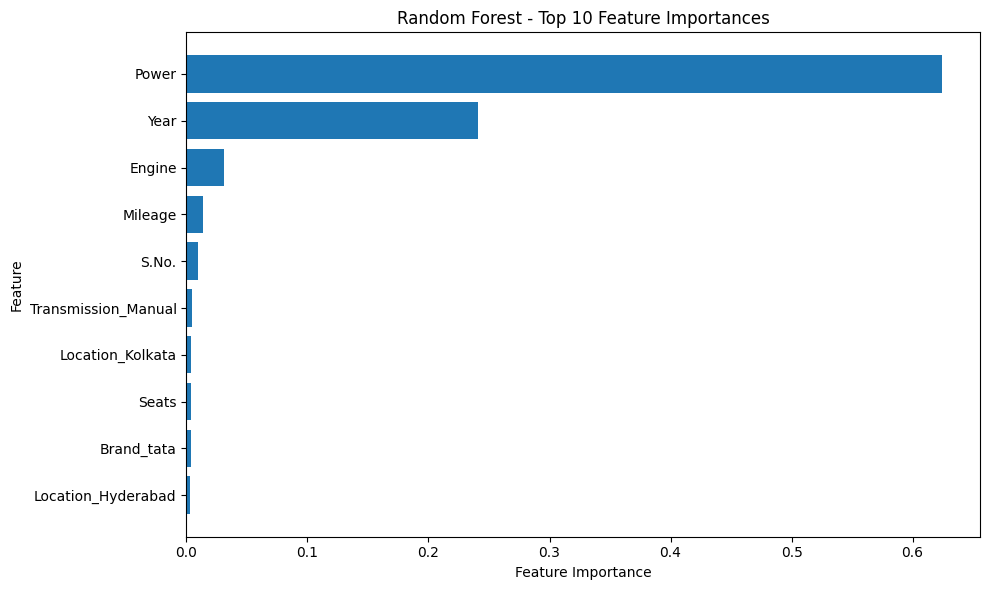

In [98]:
# Final Visualization – Feature Importance

# 1. RaNDOM Forest

import matplotlib.pyplot as plt
import pandas as pd

# Top 10 Features
rf_imp_top = rf_imp.head(10).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(rf_imp_top["Feature"], rf_imp_top["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest - Top 10 Feature Importances")
plt.tight_layout()
plt.show()

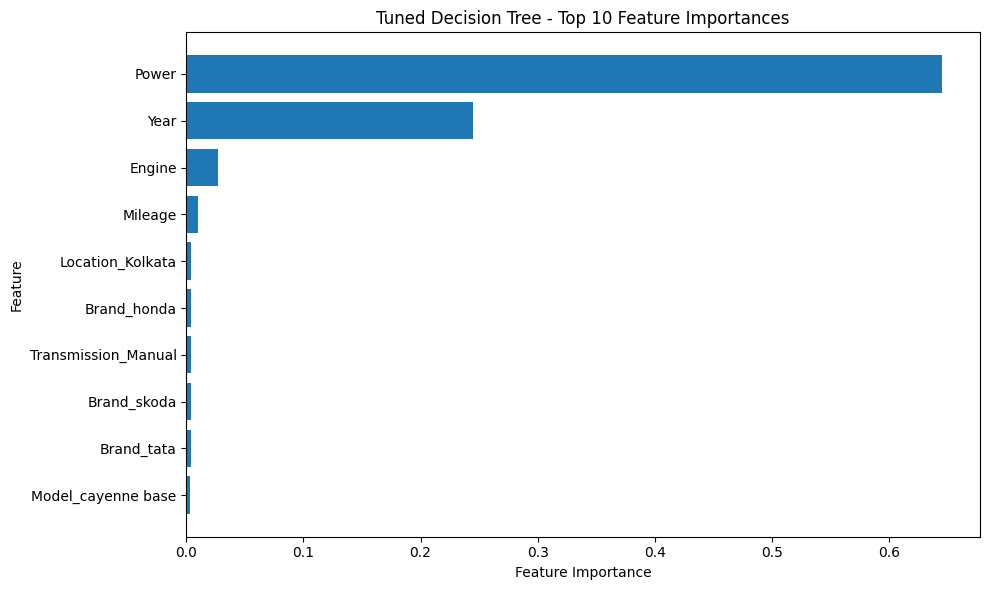

In [99]:
#2. Tuned Decision Tree
dtree_imp_top = dtree_imp.head(10).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(dtree_imp_top["Feature"], dtree_imp_top["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Tuned Decision Tree - Top 10 Feature Importances")
plt.tight_layout()
plt.show()

In [100]:
# Final REPORT - Examples and evidence that the model works
# STEP 1: Random Selection of cars, mix of different cars
# Mischung aus verschiedenen Fahrzeugtypen (besser für Story!)
# High Value Car (neu + hohe Power)
high_value = X_test.sort_values(["Year", "Power"], ascending=[False, False]).head(1)

# Low Value Car (alt + niedrige Power)
low_value = X_test.sort_values(["Year", "Power"], ascending=[True, True]).head(1)

# Typical Car (Median Bereich)
median_year = X_test["Year"].median()
median_power = X_test["Power"].median()

typical = X_test.iloc[((X_test["Year"] - median_year).abs() +
                       (X_test["Power"] - median_power).abs()).argsort()[:1]]

# Edge Case (z. B. hohe Power aber niedriger Preis)
# → wir nutzen y_test dazu
combined = X_test.copy()
combined["Price"] = y_test["Price"]

edge_case = combined.sort_values(["Power", "Price"], ascending=[False, True]).head(1)

# Final Sample
sample = pd.concat([high_value, low_value, typical, edge_case.drop(columns="Price")])


In [101]:
# STEP 2: Calculation of predictions
predictions = model.predict(sample)

In [102]:
# STEP 3: Real prices
actual_prices = y_test.loc[sample.index, "Price"]

# 🔥 WICHTIG: zurücktransformieren (falls log verwendet)
predicted_prices = np.exp(predictions)



In [103]:
# STEP 4: Final table


result = sample.copy()

result["Actual Price (Lakh INR)"] = actual_prices
result["Predicted Price (Lakh INR)"] = predicted_prices
result["Error"] = result["Predicted Price (Lakh INR)"] - result["Actual Price (Lakh INR)"]

result_display = result[[
    "Year",
    "Power",
    "Mileage",
    "Actual Price (Lakh INR)",
    "Predicted Price (Lakh INR)",
    "Error"
]].round(2).reset_index(drop=True)

result_display


,Year,Power,Mileage,Actual Price (Lakh INR),Predicted Price (Lakh INR),Error
0,2019,258.0,18.00,78.80,59.26,-19.54
1,1998,74.0,15.00,0.85,0.70,-0.15
2,2014,91.1,19.12,6.10,5.93,-0.17
3,2010,450.0,7.94,20.72,36.86,16.14


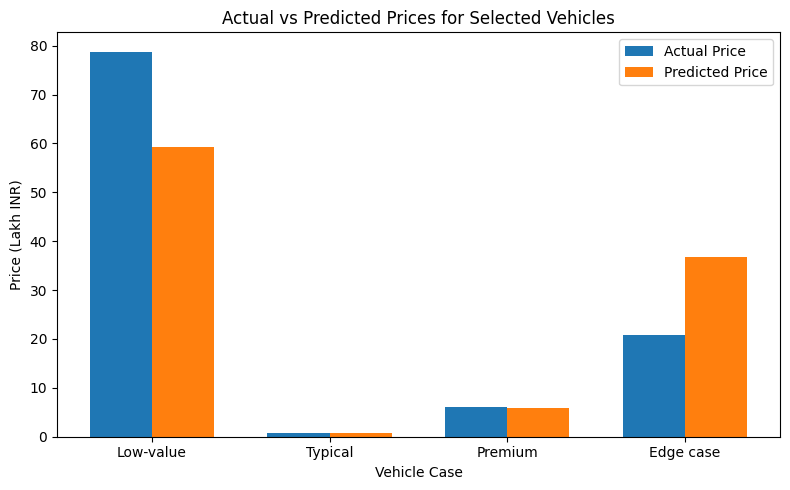

In [104]:
# Visualsiierung Tabelle
# Visualisierung Tabelle
import matplotlib.pyplot as plt
import numpy as np

# Labels manuell definieren
labels = ["Low-value", "Typical", "Premium", "Edge case"]

# Richtige Spaltennamen verwenden
actual = result_display["Actual Price (Lakh INR)"]
predicted = result_display["Predicted Price (Lakh INR)"]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, actual, width, label="Actual Price")
plt.bar(x + width/2, predicted, width, label="Predicted Price")

plt.xticks(x, labels)
plt.xlabel("Vehicle Case")
plt.ylabel("Price (Lakh INR)")
plt.title("Actual vs Predicted Prices for Selected Vehicles")

plt.legend()
plt.tight_layout()

plt.savefig("actual_vs_predicted.png", dpi=300)

plt.show()

In [105]:
# Tabelle
import pandas as pd

# Professionelle Tabelle aufbauen
table_display = result_display.copy()

# Case-Spalte ergänzen
table_display.insert(0, "Case", ["Low-value", "Typical", "Premium", "Edge case"])

# Optional: Engine ergänzen, falls du sie drin haben willst
table_display["Engine"] = result["Engine"].reset_index(drop=True).round(0)

# Spalten sauber anordnen
table_display = table_display[[
    "Case",
    "Year",
    "Power",
    "Mileage",
    "Engine",
    "Actual Price (Lakh INR)",
    "Predicted Price (Lakh INR)",
    "Error"
]]

# Werte runden
table_display = table_display.round({
    "Power": 1,
    "Mileage": 2,
    "Engine": 0,
    "Actual Price (Lakh INR)": 2,
    "Predicted Price (Lakh INR)": 2,
    "Error": 2
})

table_display

,Case,Year,Power,Mileage,Engine,Actual Price (Lakh INR),Predicted Price (Lakh INR),Error
0,Low-value,2019,258.0,18.00,2987.0,78.80,59.26,-19.54
1,Typical,1998,74.0,15.00,970.0,0.85,0.70,-0.15
2,Premium,2014,91.1,19.12,1373.0,6.10,5.93,-0.17
3,Edge case,2010,450.0,7.94,4395.0,20.72,36.86,16.14


In [106]:
# Statistischer




In [107]:
# STEP 1 Segmente definieren
df = X_test.copy()
df["Price"] = y_test["Price"]

low = df[df["Price"] < 3]
typical = df[(df["Price"] >= 3) & (df["Price"] <= 10)]
premium = df[df["Price"] > 10]

# STEP 2 Stichprobe
sample_low = low.sample(5, random_state=42)
sample_typical = typical.sample(5, random_state=42)
sample_premium = premium.sample(5, random_state=42)

sample = pd.concat([sample_low, sample_typical, sample_premium])

# STEP 3 Prediction nur auf echten Modell-Features
sample_features = sample.drop(columns=["Price"])

predictions = model.predict(sample_features)

actual_prices = sample["Price"]
predicted_prices = np.exp(predictions)   # nur wenn auf price_log trainiert

# STEP 4 Ergebnis
result = sample_features.copy()
result["Actual"] = actual_prices.values
result["Predicted"] = predicted_prices
result["Error"] = result["Predicted"] - result["Actual"]
result["Segment"] = ["Low"]*5 + ["Typical"]*5 + ["Premium"]*5

In [108]:
# Aggregation pro Segment
summary = result.groupby("Segment").agg(
    Avg_Actual=("Actual", "mean"),
    Avg_Predicted=("Predicted", "mean"),
    Avg_Error=("Error", "mean"),
    Std_Error=("Error", "std")
).round(2)

summary

,Avg_Actual,Avg_Predicted,Avg_Error,Std_Error
Segment,,,,
Low,2.33,3.06,0.74,1.04
Premium,29.52,24.43,-5.09,5.82
Typical,5.51,5.71,0.20,2.28


In [109]:
# KOMPLETTER CODE
import matplotlib.pyplot as plt
import numpy as np

# Segment-Durchschnittswerte verwenden (WICHTIG!)
labels = summary["Segment"]

actual = summary["Avg_Actual"]
predicted = summary["Avg_Predicted"]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))

bars1 = plt.bar(x - width/2, actual, width, label="Actual Price")
bars2 = plt.bar(x + width/2, predicted, width, label="Predicted Price")

plt.xticks(x, labels)
plt.xlabel("Vehicle Segment")
plt.ylabel("Price (Lakh INR)")
plt.title("Actual vs Predicted Prices by Segment")

plt.legend()
plt.tight_layout()

# Werte auf Balken anzeigen (wichtig für Report!)
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{height:.1f}", ha='center')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{height:.1f}", ha='center')

plt.savefig("actual_vs_predicted_segment.png", dpi=300, bbox_inches="tight")
plt.show()

KeyError: 'Segment'

In [ ]:
# Tabelle
# Segment Summary inkl. Sample Size
summary = result.groupby("Segment").agg(
    Sample_Size=("Actual", "count"),
    Avg_Actual=("Actual", "mean"),
    Avg_Predicted=("Predicted", "mean"),
    Avg_Error=("Error", "mean"),
    Avg_Abs_Error=("Abs Error", "mean"),
    Std_Error=("Error", "std")
).round(2).reset_index()

# Spalten umbenennen für Report
table_report = summary.copy()
table_report.columns = [
    "Segment",
    "Sample Size",
    "Average Actual Price (Lakh INR)",
    "Average Predicted Price (Lakh INR)",
    "Average Error (Lakh INR)",
    "Average Absolute Error (Lakh INR)",
    "Error Standard Deviation"
]

# Sortierung
table_report["Segment"] = pd.Categorical(
    table_report["Segment"],
    categories=["Low", "Typical", "Premium"],
    ordered=True
)

table_report = table_report.sort_values("Segment").reset_index(drop=True)

table_report

In [113]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_log = rf.predict(X_test)

ValueError: Maximum allowed size exceeded

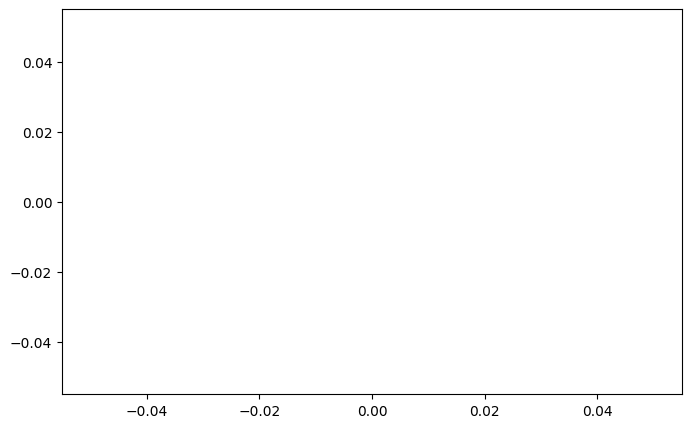

In [115]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================
# 1. Predictions (log scale)
# ============================
y_pred_log = rf.predict(X_test)   # ggf. Modellname anpassen

# ============================
# 2. Back-transform to actual prices
# ============================
y_pred_actual = np.exp(y_pred_log)
y_test_actual = np.exp(y_test)

# ============================
# 3. Residuals (ACTUAL SCALE!)
# ============================
residuals = y_test_actual - y_pred_actual

# ============================
# 4. Plot
# ============================
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)

plt.title("Residual Distribution (Actual Prices)")
plt.xlabel("Residual (INR)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("residual_plot.png", dpi=300)
plt.show()

In [112]:
print(dir())

['BaggingRegressor', 'DecisionTreeRegressor', 'Dtree_model', 'GridSearchCV', 'In', 'LR_score', 'Lasso', 'LinearRegression', 'Out', 'RandomForestRegressor', 'Ridge', 'X', 'X_test', 'X_test1', 'X_train', 'X_train1', '_', '_10', '_103', '_105', '_108', '_11', '_13', '_15', '_21', '_25', '_32', '_35', '_36', '_38', '_39', '_4', '_42', '_43', '_46', '_47', '_5', '_50', '_52', '_53', '_55', '_59', '_68', '_69', '_7', '_71', '_72', '_75', '_79', '_83', '_88', '_9', '_90', '_93', '_95', '_97', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '_dh', '_i', '_i1', '_i10', '_i100', '_i101', '_i102', '_i103', '_i104', '_i105', '_i106', '_i107', '_i108', '_i109', '_i11', '_i110', '_i111', '_i112', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28', '_i29', '_i3', '_i30', '_i31', '_i32', '_i33', '_i34', '_i35', '_i36', '_i37', '_i38', '_i39', '_i4', '_i

y_test min/max: -0.7985076962177716 79.0
y_pred_raw min/max: -0.42197244042298576 73.1435
Detected: values appear to be on actual price scale -> no back-transform
Residuals min/max: -29.04659999999999 29.231000000000016
Number of residuals: 3612


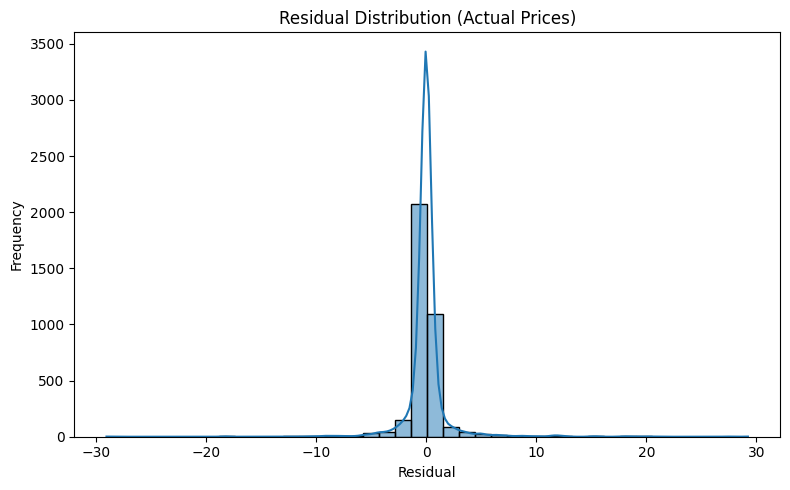

In [116]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Prediction with your trained RF model
# ==========================================
# Falls dein Modell anders heißt, rf entsprechend ersetzen
y_pred_raw = rf.predict(X_test)

# ==========================================
# 2. Inspect ranges
# ==========================================
print("y_test min/max:", np.min(y_test), np.max(y_test))
print("y_pred_raw min/max:", np.min(y_pred_raw), np.max(y_pred_raw))

# ==========================================
# 3. Detect whether values are on log scale
# Heuristic:
# - log(price) is usually in a small range, often < 10
# - actual prices are much larger
# ==========================================
use_log_backtransform = (np.nanmax(y_test) < 20) and (np.nanmax(y_pred_raw) < 20)

if use_log_backtransform:
    print("Detected: values appear to be on log scale -> applying exp back-transform")
    y_test_actual = np.exp(y_test)
    y_pred_actual = np.exp(y_pred_raw)
else:
    print("Detected: values appear to be on actual price scale -> no back-transform")
    y_test_actual = np.array(y_test)
    y_pred_actual = np.array(y_pred_raw)

# ==========================================
# 4. Residuals on actual price scale
# ==========================================
residuals = y_test_actual - y_pred_actual

# ==========================================
# 5. Remove invalid values just in case
# ==========================================
residuals = residuals[np.isfinite(residuals)]

print("Residuals min/max:", np.min(residuals), np.max(residuals))
print("Number of residuals:", len(residuals))

# ==========================================
# 6. Plot
# ==========================================
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=40, kde=True)

plt.title("Residual Distribution (Actual Prices)")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("residual_plot.png", dpi=300)
plt.show()